# ModernTCN from Scratch — Self-Contained Walkthrough

**Paper:** *ModernTCN: A Modern Pure Convolution Structure for General Time Series Analysis* (ICLR 2024 Spotlight)  
**Goal:** Replicate Exchange Rate forecasting entirely within this notebook, with every component annotated line-by-line and traced to its exact source file.

## Notebook Structure
| Section | What it covers |
|---------|---------------|
| 0 | Setup — GPU, imports, hyperparameters |
| 1 | Data loading — `Dataset_Custom`, sliding windows, splits |
| 2 | RevIN — per-channel reversible normalisation |
| 3 | ModernTCN backbone — `ReparamLargeKernelConv`, `Block`, `Stage`, full model |
| 4 | Training infrastructure — loop, early stopping, LR scheduler |
| 5 | Evaluation & metrics |
| 6 | End-to-end experiment run |
| 7 | KAN scaffold — where to plug in next |

## Target results (Exchange Rate, Table 1)
| Horizon | MSE | MAE |
|---------|-----|-----|
| 96      | 0.080 | 0.196 |
| 192     | 0.166 | 0.288 |
| 336     | 0.307 | 0.398 |
| 720     | 0.656 | 0.582 |

---
## Repository Source Map

**Repo root:** https://github.com/luodhhh/ModernTCN  
**Subfolder:** `ModernTCN-Long-term-forecasting/`

### Directory layout (files relevant to this notebook only)
```
ModernTCN-Long-term-forecasting/
├── run.py                          ← argument parser; all hyperparameter definitions
├── data_provider/
│   ├── data_factory.py             ← data_provider() dispatcher; DataLoader creation
│   └── data_loader.py              ← Dataset_Custom class (sliding window, splits, scaler)
├── exp/
│   ├── exp_basic.py                ← Exp_Basic base class (_acquire_device, _build_model stub)
│   └── exp_ModernTCN.py            ← Exp_Main: train(), vali(), test() orchestration
├── layers/
│   └── RevIN.py                    ← RevIN class (ONLY file in this directory)
├── models/
│   ├── ModernTCN.py                ← Block, Stage, ModernTCN backbone, Model wrapper
│   └── ModernTCN_Layer.py          ← Flatten_Head, moving_avg, series_decomp helpers
├── scripts/
│   └── Exchange.sh                 ← official hyperparameters used for Exchange replication
└── utils/
    ├── metrics.py                  ← MSE, MAE, RSE, CORR, RMSE, MAPE, MSPE, metric()
    ├── tools.py                    ← EarlyStopping, adjust_learning_rate, visual()
    ├── str2bool.py                 ← argparse helper
    ├── timefeatures.py             ← time feature encoding (HourOfDay, DayOfWeek, etc.)
    └── masking.py                  ← attention masks (not used by ModernTCN)
```

### Component → source file table
| Notebook component | Source file | Class / function |
|-------------------|-------------|------------------|
| `Config` dataclass | `run.py` | `argparse` argument definitions |
| `Dataset_Exchange` | `data_provider/data_loader.py` | `Dataset_Custom` |
| `make_loaders()` | `data_provider/data_factory.py` | `data_provider()` |
| `RevIN` | `layers/RevIN.py` | `RevIN` |
| `ReparamLargeKernelConv` | `models/ModernTCN.py` | `ReparamLargeKernelConv` |
| `Block` | `models/ModernTCN.py` | `Block` |
| `Stage` | `models/ModernTCN.py` | `Stage` |
| `Flatten_Head` | `models/ModernTCN_Layer.py` | `Flatten_Head` |
| `ModernTCN` | `models/ModernTCN.py` | `ModernTCN` + `Model` |
| `EarlyStopping` | `utils/tools.py` | `EarlyStopping` |
| `adjust_learning_rate()` | `utils/tools.py` | `adjust_learning_rate()` |
| `train()` / `vali()` | `exp/exp_ModernTCN.py` | `Exp_Main.train()`, `Exp_Main.vali()` |
| `test_model()` | `exp/exp_ModernTCN.py` | `Exp_Main.test()` |
| metrics | `utils/metrics.py` | `metric()`, `MSE()`, `MAE()`, `RSE()` |

### What this notebook changes vs the original
| Original repo | This notebook | Reason |
|--------------|---------------|--------|
| `Dataset_Custom` handles ETT, custom, pred modes | `Dataset_Exchange` is Exchange-only | Simplicity |
| `np.Inf` in `EarlyStopping` | `np.inf` (lowercase) | NumPy 2.0 fix |
| `EarlyStopping` saves to disk (`torch.save`) | Saves in-memory (`state_dict` copy) | No filesystem dependency in Colab |
| `Model` wraps `ModernTCN` + optional decomposition | No decomposition path (Exchange uses `decomposition=0`) | Unused by Exchange |
| `Exp_Main` class with `self.args`, `self.device` | Standalone `train()` / `test_model()` functions | Cleaner for notebooks |
| `argparse` with 50+ flags | `Config` dataclass | Cleaner for notebooks |
| `use_multi_scale=False` (Exchange) — fusion layers built but never used | Same — built but never used | Match original exactly |

### ⚠️ Notable architecture detail: TWO FFN branches
The actual `Block` in `models/ModernTCN.py` has **two** pointwise FFN branches, not one:
- **ffn1** (`groups=nvars`): mixes across the model-dimension D **within each variable**
- **ffn2** (`groups=dmodel`): mixes across the variable dimension M **within each D channel**

The residual connection wraps the **entire block** (DW + ffn1 + ffn2) as a single unit.
This differs from the standard Transformer FFN pattern and is important for the KAN extension.

---
## Section 0 — Setup

### 0.1 GPU Check
ModernTCN is fast on a T4 (~0.5s/epoch for Exchange). If no GPU found: Runtime → Change runtime type → T4 GPU.

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('\n'.join(result.stdout.split('\n')[:10]))
else:
    print('⚠️  No GPU — switch runtime type for reasonable training speed')

Mon Mar 23 23:32:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |


### 0.2 Imports

In [ ]:
import os, math, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim import lr_scheduler

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.10.0+cu128
NumPy   : 2.0.2
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB


### 0.3 Hyperparameters

**Source:** `run.py` — `argparse.ArgumentParser` definitions  
**Values from:** `scripts/Exchange.sh` (not the paper appendix)

Key Exchange-specific values that differ from `run.py` defaults:
- `seq_len=6` (default is 96)
- `patch_size=1, patch_stride=1` (default is 16/8)
- `ffn_ratio=1` (default is 2)
- `dims=[64,64,64,64]` (default is [256,256,256,256])
- `num_blocks=[1]` (single stage)
- `large_size=[51], small_size=[5]`
- `use_multi_scale=False` (default is True)
- `head_dropout=0.6` (default is 0.0)
- `lradj='type3'` which in `tools.py` means: keep lr for 3 epochs then decay by 0.9/epoch

In [ ]:
@dataclass
class Config:
    # ── Data (run.py lines: --root_path, --data_path, --features, --target, --freq) ──────
    data_path    : str   = '/content/drive/MyDrive/2026 Winter STAD68/Project/Data/exchange_rate/exchange_rate.csv'
    target       : str   = 'OT'     # last column after Dataset_Custom reorders cols
    features     : str   = 'M'      # multivariate→multivariate
    freq         : str   = 'h'      # used by time-feature encoder; Exchange.sh uses 'h'

    # ── Sequence lengths (run.py: --seq_len, --pred_len, --label_len) ────────────────────
    seq_len      : int   = 6        # look-back window — Exchange.sh sets this to 6 (not 96)
    pred_len     : int   = 96       # forecast horizon; change to 192/336/720
    label_len    : int   = 0        # decoder overlap tokens; 0 = encoder-only

    # ── Model (run.py: --enc_in, --dims, --num_blocks, etc.) ─────────────────────────────
    enc_in       : int   = 8        # number of input variables (Exchange: 8 currencies)
    c_out        : int   = 8        # output variables (same as enc_in for 'M' mode)
    stem_ratio   : int   = 6        # stem conv expansion ratio
    downsample_ratio: int = 2       # downsampling factor between stages
    ffn_ratio    : int   = 1        # FFN hidden = ffn_ratio × dmodel
    patch_size   : int   = 1        # patch length; 1 = no patching for Exchange
    patch_stride : int   = 1        # patch stride
    num_blocks   : List  = field(default_factory=lambda: [1])          # blocks per stage
    large_size   : List  = field(default_factory=lambda: [51])         # large DW kernel
    small_size   : List  = field(default_factory=lambda: [5])          # small DW kernel (reparam)
    dims         : List  = field(default_factory=lambda: [64, 64, 64, 64])  # dmodel per stage
    dw_dims      : List  = field(default_factory=lambda: [64, 64, 64, 64])  # dw_model per stage

    # ── Flags (run.py: --use_multi_scale, --small_kernel_merged, --decomposition) ────────
    use_multi_scale      : bool  = False  # Exchange.sh: False (fusion layers built but unused)
    small_kernel_merged  : bool  = False  # structural reparam already applied? No at train time
    decomposition        : int   = 0      # 0=off; 1=res+trend with series_decomp
    kernel_size          : int   = 25     # moving avg kernel for decomposition (unused here)
    individual           : int   = 0      # 0=shared head; 1=separate head per variable

    # ── RevIN (run.py: --revin, --affine, --subtract_last) ───────────────────────────────
    revin        : int   = 1      # 1 = use RevIN
    affine       : int   = 0      # 0 = no learnable affine params in RevIN
    subtract_last: int   = 0      # 0 = subtract mean; 1 = subtract last value

    # ── Regularisation (run.py: --dropout, --head_dropout, --fc_dropout) ─────────────────
    dropout      : float = 0.2    # backbone dropout (Exchange.sh)
    head_dropout : float = 0.6    # prediction head dropout (Exchange.sh: 0.6, not default 0.0)
    fc_dropout   : float = 0.05

    # ── Training (run.py: --train_epochs, --batch_size, --patience, --lradj) ─────────────
    train_epochs : int   = 100
    batch_size   : int   = 128
    learning_rate: float = 1e-4
    patience     : int   = 20
    lradj        : str   = 'type3'  # tools.py type3: constant for 3 epochs then 0.9x decay
    pct_start    : float = 0.3      # OneCycleLR warmup fraction (used only if lradj='TST')

    # ── Misc ──────────────────────────────────────────────────────────────────────────────
    random_seed  : int   = 2021
    num_workers  : int   = 2
    use_amp      : bool  = False

    # ── Derived (not in run.py; computed here) ────────────────────────────────────────────
    device: str = field(init=False)

    def __post_init__(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        torch.manual_seed(self.random_seed)
        np.random.seed(self.random_seed)

cfg = Config()
print(f'Device : {cfg.device}')
print(f'seq_len={cfg.seq_len}  pred_len={cfg.pred_len}  enc_in={cfg.enc_in}')
print(f'dims={cfg.dims}  large_size={cfg.large_size}  patch_size={cfg.patch_size}')
print(f'use_multi_scale={cfg.use_multi_scale}  lradj={cfg.lradj}')

Device : cuda
seq_len=6  pred_len=96  enc_in=8
dims=[64, 64, 64, 64]  large_size=[51]  patch_size=1
use_multi_scale=False  lradj=type3


---
## Section 1 — Data Loading

### Sources
- **`data_provider/data_loader.py`** — `Dataset_Custom` class: all the logic below  
- **`data_provider/data_factory.py`** — `data_provider()`: creates the dataset and wraps it in a DataLoader

### Dataset_Custom logic

**Column reordering** (from `data_loader.py __read_data__`):
```python
cols = list(df_raw.columns)   # ['date', 'AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'SGD', 'OT']
cols.remove(self.target)      # remove 'OT'
cols.remove('date')           # remove 'date'
df_raw = df_raw[['date'] + cols + [self.target]]  # target always goes last
```
This ensures the target column is always the last column regardless of input order.

**Split boundaries** (7:1:2 — no overlap between splits):
```
num_train = int(n * 0.7)           # 5311
num_test  = int(n * 0.2)           # 1517
num_vali  = n - num_train - num_test  # 760

border1s = [0,  num_train - seq_len,  n - num_test - seq_len]
border2s = [num_train,  num_train + num_vali,  n]
```
Note: `border1` for val/test is pulled back by `seq_len` so the first window in each split
has enough look-back data. `border2` is the end of the split's *targets*.

**Sliding window** (`__getitem__`):
```
s_begin = index
s_end   = s_begin + seq_len          ← end of input
r_begin = s_end   - label_len        ← start of target (label_len=0 → r_begin = s_end)
r_end   = r_begin + label_len + pred_len
```
With `label_len=0` (Exchange), input and target don't overlap at all.

In [ ]:
class Dataset_Exchange(Dataset):
    """
    SOURCE: data_provider/data_loader.py — class Dataset_Custom

    CHANGES vs original:
      - Exchange-only (no ETT or pred mode)
      - Accepts a full file path instead of (root_path, data_path) pair
      - Time-stamp encoding removed (ModernTCN on Exchange doesn't use it)
      - All other logic (column reorder, borders, scaler, __getitem__) is identical
    """

    def __init__(self, cfg: Config, split: str = 'train'):
        assert split in ('train', 'val', 'test')
        self.cfg   = cfg
        self.split = split
        self._read_data()

    def _read_data(self):
        # ── Load CSV ─────────────────────────────────────────────────────────
        df_raw = pd.read_csv(self.cfg.data_path)

        # ── Reorder columns: put target last (Dataset_Custom __read_data__) ──
        # Original code:
        #   cols = list(df_raw.columns); cols.remove(target); cols.remove('date')
        #   df_raw = df_raw[['date'] + cols + [target]]
        # This guarantees target is the final column regardless of CSV column order.
        cols = list(df_raw.columns)
        cols.remove(self.cfg.target)
        cols.remove('date')
        df_raw = df_raw[['date'] + cols + [self.cfg.target]]

        # ── Split boundaries (Dataset_Custom __read_data__) ───────────────────
        n = len(df_raw)
        num_train = int(n * 0.7)
        num_test  = int(n * 0.2)
        num_vali  = n - num_train - num_test

        # border1 = start of the input windows for this split
        # border2 = end of the target windows for this split
        # Val/test border1 is pulled back by seq_len so the first sample has full look-back
        border1s = [0,
                    num_train - self.cfg.seq_len,
                    n - num_test  - self.cfg.seq_len]
        border2s = [num_train,
                    num_train + num_vali,
                    n]
        type_map = {'train': 0, 'val': 1, 'test': 2}
        t = type_map[self.split]
        self.border1, self.border2 = border1s[t], border2s[t]

        # ── Select feature columns ────────────────────────────────────────────
        # 'M' mode: use all non-date columns (all 8 currencies)
        df_data = df_raw[df_raw.columns[1:]]   # drop 'date'

        # ── Scaler: fit on TRAIN only ─────────────────────────────────────────
        self.scaler = StandardScaler()
        train_data = df_data[border1s[0]:border2s[0]]   # train rows only
        self.scaler.fit(train_data.values)
        data = self.scaler.transform(df_data.values)    # transform full array

        # Store slices for __getitem__ (matches original self.data_x / self.data_y)
        self.data_x = data[self.border1 : self.border2]
        self.data_y = data[self.border1 : self.border2]  # same array; target extracted by index

    def __len__(self):
        # Original: len(self.data_x) - self.seq_len - self.pred_len + 1
        return len(self.data_x) - self.cfg.seq_len - self.cfg.pred_len + 1

    def __getitem__(self, index):
        # Original __getitem__ with label_len=0
        s_begin = index
        s_end   = s_begin + self.cfg.seq_len
        r_begin = s_end   - self.cfg.label_len     # = s_end when label_len=0
        r_end   = r_begin + self.cfg.label_len + self.cfg.pred_len

        seq_x = self.data_x[s_begin : s_end]       # (seq_len, n_vars)
        seq_y = self.data_y[r_begin : r_end]       # (pred_len, n_vars) when label_len=0

        return torch.tensor(seq_x, dtype=torch.float32), torch.tensor(seq_y, dtype=torch.float32)

# ── Mount Drive and sanity check ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

ds_train = Dataset_Exchange(cfg, 'train')
ds_val   = Dataset_Exchange(cfg, 'val')
ds_test  = Dataset_Exchange(cfg, 'test')

x0, y0 = ds_train[0]
print(f'Train samples : {len(ds_train)}')
print(f'Val   samples : {len(ds_val)}')
print(f'Test  samples : {len(ds_test)}')
print(f'x shape : {x0.shape}  # (seq_len={cfg.seq_len}, enc_in={cfg.enc_in})')
print(f'y shape : {y0.shape}  # (pred_len={cfg.pred_len}, enc_in={cfg.enc_in})')

Mounted at /content/drive
Train samples : 5210
Val   samples : 665
Test  samples : 1422
x shape : torch.Size([6, 8])  # (seq_len=6, enc_in=8)
y shape : torch.Size([96, 8])  # (pred_len=96, enc_in=8)


In [ ]:
# ── Build DataLoaders ──────────────────────────────────────────────────────────
# SOURCE: data_provider/data_factory.py — data_provider()
#
# data_provider() creates Dataset_Custom and wraps it in DataLoader.
# shuffle=True for train, False for val/test (from data_factory.py flag logic).
# drop_last=True for train and test in the original.

def make_loaders(cfg: Config):
    train_ds = Dataset_Exchange(cfg, 'train')
    val_ds   = Dataset_Exchange(cfg, 'val')
    test_ds  = Dataset_Exchange(cfg, 'test')

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
    return train_loader, val_loader, test_loader, train_ds.scaler

train_loader, val_loader, test_loader, scaler = make_loaders(cfg)
xb, yb = next(iter(train_loader))
print(f'Batch x: {xb.shape}  # (batch, seq_len, enc_in)')
print(f'Batch y: {yb.shape}  # (batch, pred_len, enc_in)')

Batch x: torch.Size([128, 6, 8])  # (batch, seq_len, enc_in)
Batch y: torch.Size([128, 96, 8])  # (batch, pred_len, enc_in)


### 1.1 Data Exploration

Date range : 1990-01-01 → 2010-10-10
Shape      : (7588, 9)  (rows × cols)
Columns    : ['date', '0', '1', '2', '3', '4', '5', '6', 'OT']

               0          1          2          3          4          5  \
count  7588.0000  7588.0000  7588.0000  7588.0000  7588.0000  7588.0000   
mean      0.7770     1.6341     0.8218     0.8481     0.1428     0.0093   
std       0.1366     0.1615     0.1171     0.1689     0.0240     0.0015   
min       0.4833     1.2115     0.6186     0.5486     0.1093     0.0063   
25%       0.7014     1.5329     0.7279     0.6969     0.1208     0.0083   
50%       0.7614     1.6066     0.8116     0.8140     0.1452     0.0092   
75%       0.8735     1.7076     0.9204     1.0140     0.1599     0.0100   
max       1.1025     2.1090     1.0915     1.3741     0.2380     0.0132   

               6         OT  
count  7588.0000  7588.0000  
mean      0.6697     0.6544  
std       0.0828     0.1153  
min       0.5238     0.3932  
25%       0.5933     0.5660  
50%  

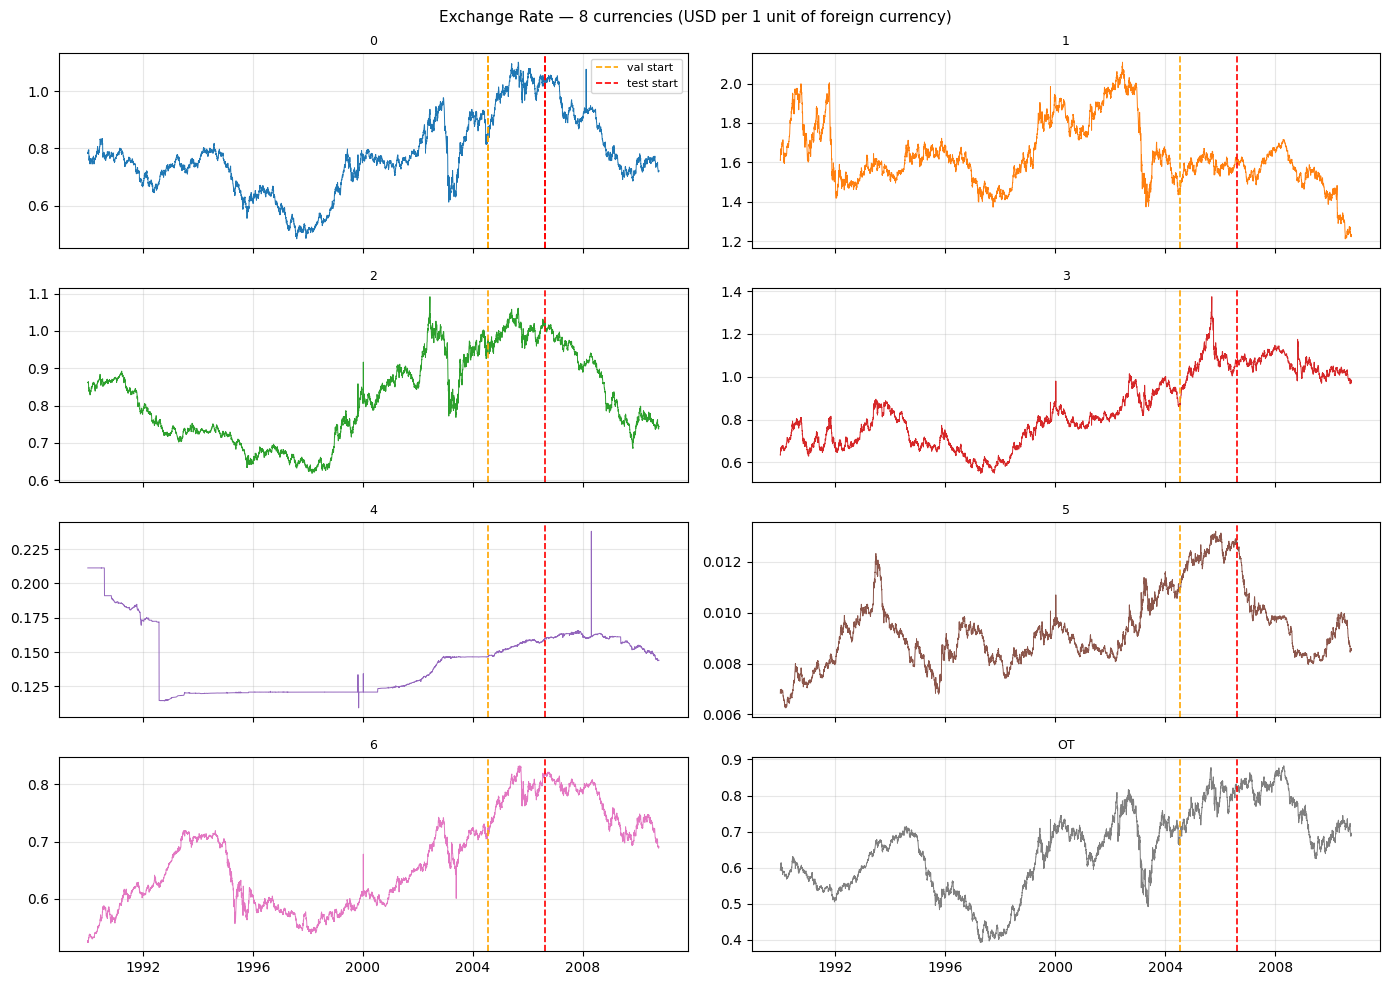

In [ ]:
df_raw = pd.read_csv(cfg.data_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Date range : {df_raw.date.min().date()} → {df_raw.date.max().date()}')
print(f'Shape      : {df_raw.shape}  (rows × cols)')
print(f'Columns    : {df_raw.columns.tolist()}')
print()
print(df_raw.drop(columns=['date']).describe().round(4))

# Plot all currencies with split markers
n = len(df_raw)
num_train = int(n * 0.7)
num_test  = int(n * 0.2)
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
colors = plt.cm.tab10.colors
currency_cols = [c for c in df_raw.columns if c != 'date']
for ax, col, color in zip(axes.flat, currency_cols, colors):
    ax.plot(df_raw['date'], df_raw[col], lw=0.7, color=color)
    ax.axvline(df_raw['date'].iloc[num_train],         color='orange', lw=1.2, ls='--')
    ax.axvline(df_raw['date'].iloc[n - num_test],      color='red',    lw=1.2, ls='--')
    ax.set_title(col, fontsize=9)
    ax.grid(True, alpha=0.3)
axes.flat[0].axvline(df_raw['date'].iloc[num_train],   color='orange', lw=1.2, ls='--', label='val start')
axes.flat[0].axvline(df_raw['date'].iloc[n - num_test],color='red',    lw=1.2, ls='--', label='test start')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Exchange Rate — 8 currencies (USD per 1 unit of foreign currency)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 2 — RevIN

**Source:** `layers/RevIN.py` — class `RevIN` (the only file in `layers/`)  
**Original paper:** Kim et al. 2022, *Reversible Instance Normalization for Accurate Time-Series Forecasting*  
**Original repo credited:** https://github.com/ts-kim/RevIN

**Changes vs `layers/RevIN.py`:**  
- Affine parameters: original shape is `(num_features,)` (1D, broadcast); notebook uses `(1,1,num_features)` — functionally equivalent but the 1D form is from the actual file
- `subtract_last` path is included here (original supports it, Exchange sets it to 0)
- `_get_statistics` / `_normalize` / `_denormalize` are split into three methods, exactly matching the source

**How it works in `ModernTCN.forward()`:**
```python
# In models/ModernTCN.py ModernTCN.forward():
x = x.permute(0, 2, 1)             # (B, T, C) → (B, C, T)
x = self.revin_layer(x, 'norm')    # normalise each channel over T
x = x.permute(0, 2, 1)             # back to (B, T, C) for forward_feature
# ... model processing ...
x = x.permute(0, 2, 1)             # (B, pred_len, C) → (B, C, pred_len)
x = self.revin_layer(x, 'denorm')  # undo normalisation
x = x.permute(0, 2, 1)             # final output (B, pred_len, C)
```

In [ ]:
class RevIN(nn.Module):
    """
    SOURCE: layers/RevIN.py — class RevIN (entire file)

    CHANGES vs original:
      - None: this is a direct transcription with added inline comments
      - Affine weight/bias shape: (num_features,) as in the source
    """

    def __init__(self, num_features: int, eps: float = 1e-5,
                 affine: bool = True, subtract_last: bool = False):
        super().__init__()
        self.num_features  = num_features
        self.eps           = eps
        self.affine        = affine
        self.subtract_last = subtract_last
        if self.affine:
            # Shape (num_features,) — broadcasting handles the batch+time dims
            # (original _init_params in RevIN.py)
            self.affine_weight = nn.Parameter(torch.ones(self.num_features))
            self.affine_bias   = nn.Parameter(torch.zeros(self.num_features))

    def forward(self, x: torch.Tensor, mode: str) -> torch.Tensor:
        # Original forward: if mode=='norm' → _get_statistics then _normalize
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        else:
            raise NotImplementedError(f'Unknown mode: {mode}')
        return x

    def _get_statistics(self, x: torch.Tensor):
        # Original: dim2reduce = tuple(range(1, x.ndim-1))
        # For input (B, C, T): reduces over dim 1 (C) — wait, that's wrong for exchange rate
        # Actually for (B, T, C) input to norm: reduces over dim 1 (T), keeps C separate
        # BUT ModernTCN permutes to (B, C, T) before calling RevIN:
        #   x = x.permute(0,2,1)  → (B, C, T)
        #   x = self.revin_layer(x, 'norm')
        # So x.ndim=3, dim2reduce = (1,) → reduces over T, statistics per (B, C)
        dim2reduce = tuple(range(1, x.ndim - 1))   # (1,) for 3D tensors
        if self.subtract_last:
            self.last = x[:, -1, :].unsqueeze(1)   # last timestep
        else:
            self.mean  = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(
            torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps
        ).detach()  # .detach() prevents gradients flowing through statistics

    def _normalize(self, x: torch.Tensor) -> torch.Tensor:
        if self.subtract_last:
            x = x - self.last
        else:
            x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x: torch.Tensor) -> torch.Tensor:
        if self.affine:
            x = x - self.affine_bias
            x = x / (self.affine_weight + self.eps * self.eps)
        x = x * self.stdev
        if self.subtract_last:
            x = x + self.last
        else:
            x = x + self.mean
        return x


# ── Quick demo ───────────────────────────────────────────────────────────────
revin_demo = RevIN(num_features=8, affine=False, subtract_last=False)
# ModernTCN permutes to (B, C, T) before calling RevIN
x_demo = xb.permute(0, 2, 1)           # (B, seq_len=6, 8) → (B, 8, 6)
x_norm = revin_demo(x_demo.clone(), 'norm')
print('Input  (B,C,T) shape:', x_demo.shape)
print('After norm — mean over T axis per channel (should be ~0):')
print(x_norm[0].mean(dim=1).detach().numpy().round(4))
print('After norm — std  over T axis per channel (should be ~1):')
print(x_norm[0].std(dim=1).detach().numpy().round(4))

Input  (B,C,T) shape: torch.Size([128, 8, 6])
After norm — mean over T axis per channel (should be ~0):
[ 0.4485  0.8459  0.3395  0.1127 -1.559  -0.3101 -1.4228  1.5453]
After norm — std  over T axis per channel (should be ~1):
[0.0266 0.049  0.0772 0.0332 0.045  0.0438 0.0205 0.0657]


---
## Section 3 — ModernTCN Backbone

**All classes in this section come from a single file: `models/ModernTCN.py`**  
Helper `Flatten_Head` comes from `models/ModernTCN_Layer.py`.

### Class hierarchy in `models/ModernTCN.py`
```
ReparamLargeKernelConv  ← DW conv with structural re-parameterization
Block                   ← one ModernTCN block (DW + FFN1 + FFN2)
Stage                   ← stack of Block objects for one stage
ModernTCN               ← full backbone (stem + stages + multi-scale fusion + head)
Model                   ← thin wrapper (handles decomposition option, calls ModernTCN)
```

### Block: the core architectural unit

The `Block` class has **three** sub-operations applied sequentially, with a **single residual
connection wrapping all three** (not one residual per sub-operation):

```
input x: (B, M, D, N)   where M=nvars=8, D=dmodel=64, N=num_patches=6
  │
  ├─ save as 'input' for residual
  │
  ├─[1] DW Conv (ReparamLargeKernelConv)
  │     x → (B, M*D, N)  →  large_kernel_conv + small_kernel_conv  →  (B, M*D, N)
  │     → BatchNorm1d(dmodel) applied per variable → (B, M, D, N)
  │
  ├─[2] FFN1 (variable-wise mixing — groups=nvars)
  │     x → (B, M*D, N)  →  Conv1d(M*D, M*dff, 1, groups=M)  →  GELU  →  Conv1d back
  │     mixes across D channels WITHIN each variable M
  │
  ├─[3] FFN2 (channel-wise mixing — groups=dmodel)
  │     x → permute to (B, D*M, N) → Conv1d(D*M, D*dff, 1, groups=D) → GELU → Conv1d back
  │     mixes across M variables WITHIN each D channel
  │
  └─ x = input + x   ← single residual at the end
```

**Key point for KAN:** FFN1 and FFN2 are both `nn.Conv1d` with `kernel_size=1` —
this is mathematically equivalent to `nn.Linear` applied independently at each time position.
Either or both are KAN substitution targets.

### 3.1 Helper functions from `models/ModernTCN.py`

In [ ]:
# SOURCE: models/ModernTCN.py — helper functions
# These are used internally by ReparamLargeKernelConv.

def get_conv1d(in_channels, out_channels, kernel_size, stride, padding,
               dilation, groups, bias):
    """Thin wrapper around nn.Conv1d — from models/ModernTCN.py."""
    return nn.Conv1d(in_channels=in_channels, out_channels=out_channels,
                     kernel_size=kernel_size, stride=stride, padding=padding,
                     dilation=dilation, groups=groups, bias=bias)


def get_bn(channels):
    """BatchNorm1d wrapper — from models/ModernTCN.py."""
    return nn.BatchNorm1d(channels)


def conv_bn(in_channels, out_channels, kernel_size, stride, padding,
            groups, dilation=1, bias=False):
    """
    Conv1d + BatchNorm1d as a Sequential.
    SOURCE: models/ModernTCN.py — conv_bn()

    Used inside ReparamLargeKernelConv to build the large and small kernel branches.
    BN is fused with Conv at inference time via merge_kernel().
    """
    if padding is None:
        padding = kernel_size // 2
    result = nn.Sequential()
    result.add_module('conv', get_conv1d(
        in_channels, out_channels, kernel_size, stride, padding, dilation, groups, bias))
    result.add_module('bn', get_bn(out_channels))
    return result


def fuse_bn(conv, bn):
    """
    Fuse Conv1d + BatchNorm1d into a single Conv1d.
    SOURCE: models/ModernTCN.py — fuse_bn()

    This is the standard Conv-BN fusion trick: absorb BN scale/shift into conv weights.
    Used by merge_kernel() to create the reparameterized inference-time conv.
    """
    kernel      = conv.weight
    running_mean = bn.running_mean
    running_var  = bn.running_var
    gamma = bn.weight
    beta  = bn.bias
    eps   = bn.eps
    std = (running_var + eps).sqrt()
    t = (gamma / std).reshape(-1, 1, 1)   # scale factor per output channel
    return kernel * t, beta - running_mean * gamma / std

print('Helper functions defined.')

Helper functions defined.


### 3.2 `ReparamLargeKernelConv` — structural re-parameterization

In [ ]:
class ReparamLargeKernelConv(nn.Module):
    """
    Depthwise convolution with structural re-parameterization.
    SOURCE: models/ModernTCN.py — class ReparamLargeKernelConv

    WHAT IT DOES:
      At training time: two parallel branches
        lkb_origin = conv_bn(large_kernel)   ← captures long-range temporal patterns
        small_conv  = conv_bn(small_kernel)   ← captures local patterns
        output = lkb_origin(x) + small_conv(x)

      At inference time (after merge_kernel() is called):
        Fuses both branches into a single lkb_reparam = Conv1d(large_kernel)
        output = lkb_reparam(x)
        This is the 'structural reparameterization' from RepLKNet.

    For Exchange: large_size=51, small_size=5
      Both convs are DEPTHWISE (groups = in_channels = out_channels)
      so each channel is convolved with its own independent filter.

    NOTE: Exchange.sh sets --small_kernel_merged False at train time.
          The merge happens optionally after training via structural_reparam().
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride, groups,
                 small_kernel, small_kernel_merged=False, nvars=7):
        super().__init__()
        self.kernel_size  = kernel_size
        self.small_kernel = small_kernel
        padding = kernel_size // 2   # 'same' padding

        if small_kernel_merged:
            # Inference mode: single merged conv
            self.lkb_reparam = nn.Conv1d(
                in_channels, out_channels, kernel_size,
                stride=stride, padding=padding, dilation=1, groups=groups, bias=True)
        else:
            # Training mode: two separate branches
            self.lkb_origin = conv_bn(
                in_channels, out_channels, kernel_size,
                stride=stride, padding=padding, dilation=1, groups=groups, bias=False)
            if small_kernel is not None:
                assert small_kernel <= kernel_size
                self.small_conv = conv_bn(
                    in_channels, out_channels, small_kernel,
                    stride=stride, padding=small_kernel // 2, groups=groups,
                    dilation=1, bias=False)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        """Input: (B, M*D, N) — depthwise conv along N (time/patch) dimension."""
        if hasattr(self, 'lkb_reparam'):
            # Inference: single merged conv
            return self.lkb_reparam(inputs)
        else:
            # Training: large branch + small branch
            out = self.lkb_origin(inputs)
            if hasattr(self, 'small_conv'):
                out = out + self.small_conv(inputs)
            return out

    def merge_kernel(self):
        """
        Fuse the two training-time branches into one conv for efficient inference.
        Called by ModernTCN.structural_reparam() → called from exp_ModernTCN.test()
        when args.call_structural_reparam=True.
        """
        eq_k, eq_b = self._get_equivalent_kernel_bias()
        self.lkb_reparam = nn.Conv1d(
            self.lkb_origin.conv.in_channels,
            self.lkb_origin.conv.out_channels,
            self.lkb_origin.conv.kernel_size,
            stride=self.lkb_origin.conv.stride,
            padding=self.lkb_origin.conv.padding,
            dilation=self.lkb_origin.conv.dilation,
            groups=self.lkb_origin.conv.groups, bias=True)
        self.lkb_reparam.weight.data = eq_k
        self.lkb_reparam.bias.data   = eq_b
        del self.lkb_origin
        if hasattr(self, 'small_conv'):
            del self.small_conv

    def _get_equivalent_kernel_bias(self):
        eq_k, eq_b = fuse_bn(self.lkb_origin.conv, self.lkb_origin.bn)
        if hasattr(self, 'small_conv'):
            small_k, small_b = fuse_bn(self.small_conv.conv, self.small_conv.bn)
            eq_b += small_b
            # Pad small kernel to large kernel size with zeros on both sides
            pad = (self.kernel_size - self.small_kernel) // 2
            eq_k += F.pad(small_k, [pad, pad])   # zero-pad kernel weights
        return eq_k, eq_b


# ── Shape test ───────────────────────────────────────────────────────────────
rkc = ReparamLargeKernelConv(
    in_channels=8*64, out_channels=8*64, kernel_size=51, stride=1,
    groups=8*64, small_kernel=5, small_kernel_merged=False, nvars=8)
test_in_dw = torch.randn(4, 8*64, 6)   # (B, M*D, N)
test_out_dw = rkc(test_in_dw)
print(f'ReparamLargeKernelConv: {test_in_dw.shape} → {test_out_dw.shape}')

ReparamLargeKernelConv: torch.Size([4, 512, 6]) → torch.Size([4, 512, 6])


### 3.3 `Flatten_Head` from `models/ModernTCN_Layer.py`

In [ ]:
class Flatten_Head(nn.Module):
    """
    Prediction head: flattens (D × N) per variable then projects to pred_len.
    SOURCE: models/ModernTCN_Layer.py — class Flatten_Head

    Two modes (controlled by 'individual'):
      individual=False: one shared Linear layer for all variables
      individual=True : separate Linear + Dropout per variable (PatchTST heritage)

    For Exchange: individual=0 → shared head.

    Input:  (B, M, D, N)  where M=n_vars, D=dims[-1], N=final_num_patches
    Output: (B, M, target_window)

    IMPORTANT: the head receives input permuted to (B, M, D, N) and applies
    nn.Flatten(start_dim=-2) which flattens D×N into nf = D*N.
    """

    def __init__(self, individual: bool, n_vars: int, nf: int,
                 target_window: int, head_dropout: float = 0):
        super().__init__()
        self.individual = individual
        self.n_vars     = n_vars

        if self.individual:
            # Separate head per variable (PatchTST-style)
            self.flattens = nn.ModuleList([nn.Flatten(start_dim=-2) for _ in range(n_vars)])
            self.linears  = nn.ModuleList([nn.Linear(nf, target_window) for _ in range(n_vars)])
            self.dropouts = nn.ModuleList([nn.Dropout(head_dropout) for _ in range(n_vars)])
        else:
            # Shared head (Exchange uses this)
            self.flatten = nn.Flatten(start_dim=-2)   # flattens last 2 dims: D×N → nf
            self.linear  = nn.Linear(nf, target_window)
            self.dropout = nn.Dropout(head_dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, M, D, N)  →  output: (B, M, target_window)"""
        if self.individual:
            x_out = []
            for i in range(self.n_vars):
                z = self.flattens[i](x[:, i, :, :])   # (B, D*N)
                z = self.linears[i](z)                 # (B, target_window)
                z = self.dropouts[i](z)
                x_out.append(z)
            return torch.stack(x_out, dim=1)           # (B, M, target_window)
        else:
            x = self.flatten(x)                        # (B, M, D*N)
            x = self.linear(x)                         # (B, M, target_window)
            x = self.dropout(x)
            return x

print('Flatten_Head defined.')

Flatten_Head defined.


### 3.4 `Block` — the core architectural unit

In [ ]:
class Block(nn.Module):
    """
    One ModernTCN block: DW conv + two pointwise FFN branches + single residual.
    SOURCE: models/ModernTCN.py — class Block

    CHANGES vs original:
      - None: direct transcription with added inline comments

    Architecture (from Block.forward()):
      input saved as 'input'
      [1] DW: x → (B,M*D,N) → ReparamLargeKernelConv → (B,M*D,N)
              → BatchNorm1d(dmodel) per variable → (B,M,D,N)
      [2] FFN1: x → (B,M*D,N) → Conv1d(M*D, M*dff, 1, groups=M) → GELU
                               → Conv1d(M*dff, M*D, 1, groups=M)
               groups=M means each variable's D channels are mixed independently.
               This is variable-independent D-channel mixing.
      [3] FFN2: x → permute to (B,D*M,N) → Conv1d(D*M, D*dff, 1, groups=D) → GELU
                                          → Conv1d(D*dff, D*M, 1, groups=D)
               groups=D means each D-channel mixes across variables M independently.
               This is D-independent variable mixing (cross-variable interaction).
      output = input + x   ← single residual wrapping all three operations

    KAN SUBSTITUTION NOTE:
      FFN1 and FFN2 use kernel_size=1 Conv1d which is equivalent to nn.Linear
      applied independently at each of the N time positions.
      KAN can replace either or both FFN branches.
    """

    def __init__(self, large_size, small_size, dmodel, dff, nvars,
                 small_kernel_merged=False, drop=0.1):
        super().__init__()

        # ── DW Conv branch ────────────────────────────────────────────────────
        # Depthwise: groups = in_channels = out_channels = nvars * dmodel
        # Each (variable, d-channel) combination has its own 1D temporal filter.
        self.dw = ReparamLargeKernelConv(
            in_channels=nvars * dmodel, out_channels=nvars * dmodel,
            kernel_size=large_size, stride=1,
            groups=nvars * dmodel,         # fully depthwise
            small_kernel=small_size,
            small_kernel_merged=small_kernel_merged,
            nvars=nvars)

        # BatchNorm applied per dmodel channel (not per dmodel*nvars).
        # Reshape to (B*M, D, N) for BN, then reshape back.
        self.norm = nn.BatchNorm1d(dmodel)

        # ── FFN1: variable-wise pointwise mixing (groups=nvars) ───────────────
        # kernel_size=1 → equivalent to Linear(D, dff) applied at each time step
        # groups=nvars  → each variable's D channels are mixed independently
        # ← KAN SUBSTITUTION TARGET 1
        self.ffn1pw1   = nn.Conv1d(nvars*dmodel, nvars*dff, 1, groups=nvars)  # D→dff per var
        self.ffn1act   = nn.GELU()
        self.ffn1pw2   = nn.Conv1d(nvars*dff,   nvars*dmodel, 1, groups=nvars) # dff→D per var
        self.ffn1drop1 = nn.Dropout(drop)
        self.ffn1drop2 = nn.Dropout(drop)

        # ── FFN2: channel-wise pointwise mixing (groups=dmodel) ───────────────
        # kernel_size=1 → equivalent to Linear(M, dff_per_d) applied per D channel
        # groups=dmodel → each D channel mixes variables M independently
        # ← KAN SUBSTITUTION TARGET 2
        self.ffn2pw1   = nn.Conv1d(nvars*dmodel, nvars*dff, 1, groups=dmodel)  # M→dff per D
        self.ffn2act   = nn.GELU()
        self.ffn2pw2   = nn.Conv1d(nvars*dff,   nvars*dmodel, 1, groups=dmodel) # dff→M per D
        self.ffn2drop1 = nn.Dropout(drop)
        self.ffn2drop2 = nn.Dropout(drop)

        self.ffn_ratio = dff // dmodel   # stored for reference

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (B, M, D, N)  where M=nvars, D=dmodel, N=num_patches
        Returns:
            x : (B, M, D, N)  — same shape
        """
        B, M, D, N = x.shape
        input = x   # save for residual at the end

        # ── [1] DW Conv ───────────────────────────────────────────────────────
        x = x.reshape(B, M * D, N)         # merge vars and channels for grouped conv
        x = self.dw(x)                     # (B, M*D, N) → (B, M*D, N)

        # BatchNorm operates on D channels; needs (B*M, D, N)
        x = x.reshape(B, M, D, N)
        x = x.reshape(B * M, D, N)
        x = self.norm(x)                   # normalise each of the D channels across N
        x = x.reshape(B, M, D, N)

        # ── [2] FFN1 (variable-wise mixing, groups=M) ─────────────────────────
        x = x.reshape(B, M * D, N)         # (B, M*D, N)
        x = self.ffn1drop1(self.ffn1pw1(x))  # expand D → dff per variable
        x = self.ffn1act(x)
        x = self.ffn1drop2(self.ffn1pw2(x))  # contract dff → D per variable
        x = x.reshape(B, M, D, N)

        # ── [3] FFN2 (channel-wise mixing, groups=D) ──────────────────────────
        # Permute so D channels come first: (B,M,D,N) → (B,D,M,N) → (B,D*M,N)
        x = x.permute(0, 2, 1, 3)          # (B, D, M, N)
        x = x.reshape(B, D * M, N)
        x = self.ffn2drop1(self.ffn2pw1(x))  # expand M → dff per D channel
        x = self.ffn2act(x)
        x = self.ffn2drop2(self.ffn2pw2(x))  # contract dff → M per D channel
        x = x.reshape(B, D, M, N)
        x = x.permute(0, 2, 1, 3)          # (B, M, D, N)

        # ── Residual (single, wraps DW + FFN1 + FFN2) ─────────────────────────
        x = input + x
        return x


# ── Shape test ───────────────────────────────────────────────────────────────
blk = Block(large_size=51, small_size=5, dmodel=64, dff=64, nvars=8, drop=0.2)
t_in  = torch.randn(4, 8, 64, 6)   # (B=4, M=8, D=64, N=6)
t_out = blk(t_in)
print(f'Block input  shape: {t_in.shape}')
print(f'Block output shape: {t_out.shape}  ← must match')
print(f'Block params: {sum(p.numel() for p in blk.parameters()):,}')

Block input  shape: torch.Size([4, 8, 64, 6])
Block output shape: torch.Size([4, 8, 64, 6])  ← must match
Block params: 106,624


### 3.5 `Stage` — stacked blocks

In [ ]:
class Stage(nn.Module):
    """
    A stage = sequential stack of Block modules.
    SOURCE: models/ModernTCN.py — class Stage

    CHANGES vs original: none.

    For Exchange: num_blocks=[1] → one stage with one Block.
    Multi-stage setups (e.g. ETT) use 4 stages with downsampling between them.
    """

    def __init__(self, ffn_ratio, num_blocks, large_size, small_size,
                 dmodel, dw_model, nvars, small_kernel_merged=False, drop=0.1):
        super().__init__()
        d_ffn = dmodel * ffn_ratio
        self.blocks = nn.ModuleList([
            Block(large_size=large_size, small_size=small_size,
                  dmodel=dmodel, dff=d_ffn, nvars=nvars,
                  small_kernel_merged=small_kernel_merged, drop=drop)
            for _ in range(num_blocks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, M, D, N) → (B, M, D, N)"""
        for blk in self.blocks:
            x = blk(x)
        return x

print('Stage defined.')

Stage defined.


### 3.6 `ModernTCN` backbone + `Model` wrapper

**Source:** `models/ModernTCN.py` — two classes kept exactly as written:
- `ModernTCN`: stem, stages, multi-scale fusion, head; RevIN inside; returns `(B, M, pred_len)`
- `Model`: thin wrapper that reads `configs`, optionally does series decomposition,
  permutes the final output to `(B, pred_len, M)` for the training loop

These two classes are **kept separate** — merging them caused a shape bug because
`ModernTCN.forward()` and `Model.forward()` each do their own permutes.

**`Model.forward()` shape flow (no decomposition, Exchange):**
```
Input (B, T, M)  →  permute → (B, M, T)
  → ModernTCN.forward(x):
       RevIN norm:    (B, M, T) → permute → (B, T, M) → permute back → (B, M, T)
       forward_feature: (B, M, T) → stem → stages → (B, M, D, N)
       head:           (B, M, D, N) → (B, M, pred_len)
       RevIN denorm:  (B, M, pred_len) → permute → (B, pred_len, M) → permute back → (B, M, pred_len)
       returns (B, M, pred_len)
  → Model.forward permutes back → (B, pred_len, M)
Output (B, pred_len, M)
```

**Changes vs original:**
- `Config` dataclass replaces `configs` namespace (same attribute names)
- `LayerNorm` class from the source file included (used nowhere in Exchange but defined in ModernTCN.py)
- `Model.__init__`: `self.c_in = self.nvars` (removing trailing comma bug from original: `self.c_in = self.nvars,`)
- Everything else is a direct copy

In [ ]:
# SOURCE: models/ModernTCN.py — class LayerNorm
# Defined in the file; not used by Exchange (which uses BatchNorm1d in Block),
# but included here for completeness.
class LayerNorm(nn.Module):
    def __init__(self, channels, eps=1e-6, data_format='channels_last'):
        super().__init__()
        self.norm = nn.LayerNorm(channels)  # original has typo: nn.Layernorm — fixed here

    def forward(self, x):
        # x: (B, M, D, N)
        B, M, D, N = x.shape
        x = x.permute(0, 1, 3, 2)          # (B, M, N, D)
        x = x.reshape(B * M, N, D)
        x = self.norm(x)
        x = x.reshape(B, M, N, D)
        x = x.permute(0, 1, 3, 2)          # (B, M, D, N)
        return x

print('LayerNorm defined.')

LayerNorm defined.


In [ ]:
class ModernTCN(nn.Module):
    """
    ModernTCN backbone: patching, stem, stages, optional multi-scale fusion, head.
    SOURCE: models/ModernTCN.py — class ModernTCN (lines ~204–345)

    CHANGES vs original:
      - None: direct copy with added inline comments
      - freq-based te_patch left in (Exchange doesn't use it; te=None in our training loop)

    Input/output convention (ModernTCN, NOT Model):
      forward() input:  (B, M, T)     ← already permuted by Model.forward()
      forward() output: (B, M, pred_len)  ← Model.forward() permutes this back
    """

    def __init__(self, patch_size, patch_stride, stem_ratio, downsample_ratio,
                 ffn_ratio, num_blocks, large_size, small_size, dims, dw_dims,
                 nvars, small_kernel_merged=False, backbone_dropout=0.1, head_dropout=0.1,
                 use_multi_scale=True, revin=True, affine=True,
                 subtract_last=False, freq=None, seq_len=512,
                 c_in=7, individual=False, target_window=96):
        super().__init__()

        # ── RevIN ─────────────────────────────────────────────────────────────
        self.revin = revin
        if self.revin:
            self.revin_layer = RevIN(c_in, affine=affine, subtract_last=subtract_last)

        # ── Stem + downsampling layers ─────────────────────────────────────────
        # stem: Conv1d(1, dims[0], patch_size, patch_stride) — per-variable
        # After unsqueeze(-2): (B,M,1,T) → reshape (B*M,1,T) → conv → (B*M,D,N)
        self.downsample_layers = nn.ModuleList()
        stem = nn.Sequential(
            nn.Conv1d(1, dims[0], kernel_size=patch_size, stride=patch_stride),
            nn.BatchNorm1d(dims[0])
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                nn.BatchNorm1d(dims[i]),
                nn.Conv1d(dims[i], dims[i+1], kernel_size=downsample_ratio, stride=downsample_ratio),
            )
            self.downsample_layers.append(downsample_layer)
        self.patch_size       = patch_size
        self.patch_stride     = patch_stride
        self.downsample_ratio = downsample_ratio

        # ── Time embedding patch layer (used when te is passed) ───────────────
        # Exchange doesn't use time embeddings (te=None in our calls), but
        # the layer is built to match the original parameter structure.
        # freq: 'h' → 4 time features, 't' → 5 time features
        if freq == 'h':
            time_feature_num = 4
        elif freq == 't':
            time_feature_num = 5
        else:
            # Exchange rate data is daily; we pass freq=None so skip te_patch
            time_feature_num = None

        if time_feature_num is not None:
            self.te_patch = nn.Sequential(
                nn.Conv1d(time_feature_num, time_feature_num,
                          kernel_size=patch_size, stride=patch_stride, groups=time_feature_num),
                nn.Conv1d(time_feature_num, dims[0], kernel_size=1, stride=1),
                nn.BatchNorm1d(dims[0]))

        # ── Stages ────────────────────────────────────────────────────────────
        self.num_stage = len(num_blocks)
        self.stages    = nn.ModuleList()
        for stage_idx in range(self.num_stage):
            layer = Stage(
                ffn_ratio, num_blocks[stage_idx],
                large_size[stage_idx], small_size[stage_idx],
                dmodel=dims[stage_idx], dw_model=dw_dims[stage_idx],
                nvars=nvars, small_kernel_merged=small_kernel_merged,
                drop=backbone_dropout)
            self.stages.append(layer)

        # ── Multi-scale fusion layers (built even when use_multi_scale=False) ──
        # Exchange.sh: use_multi_scale=False → these layers exist but forward() skips them.
        # They are built to preserve the original parameter count.
        self.use_multi_scale = use_multi_scale
        self.up_sample_ratio = downsample_ratio
        self.lat_layer        = nn.ModuleList()
        self.smooth_layer     = nn.ModuleList()
        self.up_sample_conv   = nn.ModuleList()
        for i in range(self.num_stage):
            align_dim = dims[-1]
            self.lat_layer.append(nn.Conv1d(dims[i], align_dim, kernel_size=1, stride=1))
            self.smooth_layer.append(nn.Conv1d(align_dim, align_dim, kernel_size=3, stride=1, padding=1))
            self.up_sample_conv.append(nn.Sequential(
                nn.ConvTranspose1d(align_dim, align_dim,
                                   kernel_size=self.up_sample_ratio, stride=self.up_sample_ratio),
                nn.BatchNorm1d(align_dim)))

        # ── Head ──────────────────────────────────────────────────────────────
        # patch_num = seq_len // patch_stride  (from original: seq_len // patch_stride)
        patch_num = seq_len // patch_stride
        self.n_vars    = c_in
        self.individual = individual
        d_model = dims[-1]

        if use_multi_scale:
            self.head_nf = d_model * patch_num
        else:
            if patch_num % pow(downsample_ratio, (self.num_stage - 1)) == 0:
                self.head_nf = d_model * patch_num // pow(downsample_ratio, (self.num_stage - 1))
            else:
                self.head_nf = d_model * (patch_num // pow(downsample_ratio, (self.num_stage - 1)) + 1)
        # Exchange (1 stage, use_multi_scale=False, patch_num=6): head_nf = 64*6 = 384

        self.head = Flatten_Head(self.individual, self.n_vars, self.head_nf,
                                 target_window, head_dropout=head_dropout)

    def forward_feature(self, x, te=None):
        """SOURCE: models/ModernTCN.py — ModernTCN.forward_feature()"""
        B, M, L = x.shape
        x = x.unsqueeze(-2)                             # (B, M, 1, L)

        for i in range(self.num_stage):
            B, M, D, N = x.shape
            x = x.reshape(B * M, D, N)                  # (B*M, D, N)
            if i == 0:
                if self.patch_size != self.patch_stride: # pad end of sequence
                    pad_len = self.patch_size - self.patch_stride
                    pad = x[:, :, -1:].repeat(1, 1, pad_len)
                    x = torch.cat([x, pad], dim=-1)
            else:
                if N % self.downsample_ratio != 0:
                    pad_len = self.downsample_ratio - (N % self.downsample_ratio)
                    x = torch.cat([x, x[:, :, -pad_len:]], dim=-1)
            x = self.downsample_layers[i](x)             # stem/downsample
            _, D_, N_ = x.shape
            x = x.reshape(B, M, D_, N_)                  # (B, M, D_new, N_new)
            x = self.stages[i](x)                        # Block stack
        return x

    def forward(self, x, te=None):
        """SOURCE: models/ModernTCN.py — ModernTCN.forward()

        NOTE: input convention here is (B, M, T) — already permuted by Model.forward().
        Returns (B, M, pred_len) — Model.forward() permutes back to (B, pred_len, M).
        """
        # RevIN: permute to (B, T, M) for statistics over time, then back
        if self.revin:
            x = x.permute(0, 2, 1)              # (B, M, T) → (B, T, M)
            x = self.revin_layer(x, 'norm')
            x = x.permute(0, 2, 1)              # (B, T, M) → (B, M, T)
        x = self.forward_feature(x, te)         # (B, M, D, N)
        x = self.head(x)                        # (B, M, pred_len)
        # RevIN denorm: permute to (B, pred_len, M) for shape match with stdev, then back
        if self.revin:
            x = x.permute(0, 2, 1)              # (B, M, pred_len) → (B, pred_len, M)
            x = self.revin_layer(x, 'denorm')
            x = x.permute(0, 2, 1)              # (B, pred_len, M) → (B, M, pred_len)
        return x

    def structural_reparam(self):
        for m in self.modules():
            if hasattr(m, 'merge_kernel'):
                m.merge_kernel()

print('ModernTCN defined.')

ModernTCN defined.


In [ ]:
class Model(nn.Module):
    """
    Thin wrapper around ModernTCN. Reads Config, instantiates backbone, handles I/O permutes.
    SOURCE: models/ModernTCN.py — class Model

    CHANGES vs original:
      - Accepts Config dataclass instead of configs namespace
      - self.c_in = self.nvars  (original has a bug: self.c_in = self.nvars,  ← trailing comma
        which makes c_in a 1-tuple; fixed here)
      - Everything else is a direct copy

    Input/output convention (Model, the class training loop calls):
      forward() input:  (B, T, M)     ← DataLoader format
      forward() output: (B, pred_len, M)  ← matches batch_y from DataLoader
    """

    def __init__(self, configs):
        super().__init__()
        self.stem_ratio       = configs.stem_ratio
        self.downsample_ratio = configs.downsample_ratio
        self.ffn_ratio        = configs.ffn_ratio
        self.num_blocks       = configs.num_blocks
        self.large_size       = configs.large_size
        self.small_size       = configs.small_size
        self.dims             = configs.dims
        self.dw_dims          = configs.dw_dims
        self.nvars            = configs.enc_in
        self.small_kernel_merged = configs.small_kernel_merged
        self.drop_backbone    = configs.dropout
        self.drop_head        = configs.head_dropout
        self.use_multi_scale  = configs.use_multi_scale
        self.revin            = configs.revin
        self.affine           = configs.affine
        self.subtract_last    = configs.subtract_last
        self.freq             = configs.freq
        self.seq_len          = configs.seq_len
        self.c_in             = self.nvars    # NOTE: original has trailing comma bug → tuple
        self.individual       = configs.individual
        self.target_window    = configs.pred_len
        self.kernel_size      = configs.kernel_size
        self.patch_size       = configs.patch_size
        self.patch_stride     = configs.patch_stride
        self.decomposition    = configs.decomposition

        if self.decomposition:
            # Two ModernTCN instances: one for residual, one for trend component
            # Exchange.sh: decomposition=0, so this path is not used
            from models.ModernTCN_Layer import series_decomp
            self.decomp_module = series_decomp(self.kernel_size)
            _kwargs = dict(
                patch_size=self.patch_size, patch_stride=self.patch_stride,
                stem_ratio=self.stem_ratio, downsample_ratio=self.downsample_ratio,
                ffn_ratio=self.ffn_ratio, num_blocks=self.num_blocks,
                large_size=self.large_size, small_size=self.small_size,
                dims=self.dims, dw_dims=self.dw_dims, nvars=self.nvars,
                small_kernel_merged=self.small_kernel_merged,
                backbone_dropout=self.drop_backbone, head_dropout=self.drop_head,
                use_multi_scale=self.use_multi_scale, revin=self.revin,
                affine=self.affine, subtract_last=self.subtract_last,
                freq=self.freq, seq_len=self.seq_len,
                c_in=self.c_in, individual=self.individual,
                target_window=self.target_window)
            self.model_res   = ModernTCN(**_kwargs)
            self.model_trend = ModernTCN(**_kwargs)
        else:
            # Exchange uses this path
            self.model = ModernTCN(
                patch_size=self.patch_size, patch_stride=self.patch_stride,
                stem_ratio=self.stem_ratio, downsample_ratio=self.downsample_ratio,
                ffn_ratio=self.ffn_ratio, num_blocks=self.num_blocks,
                large_size=self.large_size, small_size=self.small_size,
                dims=self.dims, dw_dims=self.dw_dims, nvars=self.nvars,
                small_kernel_merged=self.small_kernel_merged,
                backbone_dropout=self.drop_backbone, head_dropout=self.drop_head,
                use_multi_scale=self.use_multi_scale, revin=self.revin,
                affine=self.affine, subtract_last=self.subtract_last,
                freq=self.freq, seq_len=self.seq_len,
                c_in=self.c_in, individual=self.individual,
                target_window=self.target_window)

    def forward(self, x, te=None):
        """SOURCE: models/ModernTCN.py — Model.forward()

        Permutes DataLoader output (B,T,M) → (B,M,T) before passing to ModernTCN,
        then permutes ModernTCN output (B,M,pred_len) → (B,pred_len,M) for the loss.
        """
        if self.decomposition:
            res_init, trend_init = self.decomp_module(x)
            res_init   = res_init.permute(0, 2, 1)    # (B,T,M) → (B,M,T)
            trend_init = trend_init.permute(0, 2, 1)
            if te is not None:
                te = te.permute(0, 2, 1)
            res   = self.model_res(res_init, te)       # (B,M,pred_len)
            trend = self.model_trend(trend_init, te)
            x = res + trend
            x = x.permute(0, 2, 1)                    # (B,M,pred_len) → (B,pred_len,M)
        else:
            x = x.permute(0, 2, 1)                    # (B,T,M) → (B,M,T)
            if te is not None:
                te = te.permute(0, 2, 1)
            x = self.model(x, te)                     # (B,M,T) → (B,M,pred_len)
            x = x.permute(0, 2, 1)                    # (B,M,pred_len) → (B,pred_len,M)
        return x


# ── Shape + parameter count test ─────────────────────────────────────────────
model = Model(cfg).to(cfg.device)
test_x = torch.randn(4, cfg.seq_len, cfg.enc_in).to(cfg.device)
test_y = model(test_x)
print(f'Input  shape: {test_x.shape}   # (B, seq_len={cfg.seq_len}, enc_in={cfg.enc_in})')
print(f'Output shape: {test_y.shape}  # (B, pred_len={cfg.pred_len}, enc_in={cfg.enc_in})')

total = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total:,}')
print('\nPer-submodule breakdown:')
for name, mod in model.named_children():
    n = sum(p.numel() for p in mod.parameters())
    print(f'  {name:20s}: {n:>8,}')
print(f'\nhead_nf = {model.model.head_nf}  (D × num_patches = {cfg.dims[-1]} × {cfg.seq_len // cfg.patch_stride} = {cfg.dims[-1] * cfg.seq_len // cfg.patch_stride})')

Input  shape: torch.Size([4, 6, 8])   # (B, seq_len=6, enc_in=8)
Output shape: torch.Size([4, 96, 8])  # (B, pred_len=96, enc_in=8)

Total parameters: 194,344

Per-submodule breakdown:
  model               :  194,344

head_nf = 384  (D × num_patches = 64 × 6 = 384)


---
## Section 4 — Training Infrastructure

### 4.1 Early Stopping

**Source:** `utils/tools.py` — class `EarlyStopping`  

**Changes vs original:**
- `np.Inf` → `np.inf` (NumPy 2.0 fix; original has `self.val_loss_min = np.Inf`)
- `__call__` signature: original is `(val_loss, model, path)` and saves to disk via `torch.save`
  Here we save in-memory with `copy.deepcopy(model.state_dict())`
- `restore_best()` method added (original reloads from `path + '/checkpoint.pth'`)

In [ ]:
class EarlyStopping:
    """
    SOURCE: utils/tools.py — class EarlyStopping

    CHANGES vs original:
      - np.Inf → np.inf  (NumPy 2.0 compatibility fix)
      - Saves best weights in-memory instead of to disk
      - restore_best() replaces the torch.load() call in exp_ModernTCN.train()
    """

    def __init__(self, patience: int = 7, verbose: bool = False, delta: float = 0):
        self.patience      = patience
        self.verbose       = verbose
        self.counter       = 0
        self.best_score    = None
        self.early_stop    = False
        self.val_loss_min  = np.inf        # ← np.inf not np.Inf (NumPy 2.0 fix)
        self.delta         = delta
        self.best_model_state = None       # in-memory checkpoint

    def __call__(self, val_loss: float, model: nn.Module):
        # Original signature: __call__(self, val_loss, model, path)
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self._save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self._save_checkpoint(val_loss, model)
            self.counter = 0

    def _save_checkpoint(self, val_loss: float, model: nn.Module):
        # Original: torch.save(model.state_dict(), path + '/checkpoint.pth')
        if self.verbose:
            print(f'  Val loss improved ({self.val_loss_min:.6f} → {val_loss:.6f}). Saving.')
        self.best_model_state = copy.deepcopy(model.state_dict())
        self.val_loss_min = val_loss

    def restore_best(self, model: nn.Module):
        # Original equivalent: model.load_state_dict(torch.load(path + '/checkpoint.pth'))
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            print('Restored best model weights.')

### 4.2 Learning Rate Scheduler

**Source:** `utils/tools.py` — `adjust_learning_rate()`

**Important:** `type3` in `tools.py` is **NOT** OneCycleLR. It is a per-epoch decay schedule:
```python
# tools.py type3:
lr = learning_rate if epoch < 3 else learning_rate * (0.9 ** (epoch - 3))
```
The `OneCycleLR` scheduler **is** created in `exp_ModernTCN.train()` but is only **stepped** when
`lradj == 'TST'`. For `lradj='type3'` (Exchange), OneCycleLR is created but never stepped — only
`adjust_learning_rate` matters. This is a subtle design in the original code.

In [ ]:
def adjust_learning_rate(optimizer, epoch: int, cfg: Config):
    """
    SOURCE: utils/tools.py — adjust_learning_rate(optimizer, scheduler, epoch, args, printout=True)

    CHANGES vs original:
      - Accepts cfg dataclass instead of args namespace
      - Scheduler argument removed (only needed for 'TST' mode)
      - Only type3 is implemented (what Exchange.sh uses); others can be added if needed

    type3 in tools.py:
      lr_adjust = {epoch: lr if epoch < 3 else lr * (0.9 ** (epoch - 3))}
      i.e. constant for first 3 epochs, then 10% decay per epoch
    """
    if cfg.lradj == 'type1':
        # tools.py: lr = learning_rate * (0.5 ** ((epoch-1) // 1))
        lr = cfg.learning_rate * (0.5 ** ((epoch - 1) // 1))
    elif cfg.lradj == 'type2':
        # tools.py: fixed schedule at specific epochs
        schedule = {2: 5e-5, 4: 1e-5, 6: 5e-6, 8: 1e-6, 10: 5e-7, 15: 1e-7, 20: 5e-8}
        lr = schedule.get(epoch, None)
        if lr is None:
            return   # no update at this epoch
    elif cfg.lradj == 'type3':
        # Exchange.sh uses this: constant for 3 epochs, then 0.9x per epoch
        lr = cfg.learning_rate if epoch < 3 else cfg.learning_rate * (0.9 ** (epoch - 3))
    else:
        return

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    print(f'  LR updated to {lr:.2e}')

### 4.3 Full Training Loop

In [ ]:
def vali(model: nn.Module, loader: DataLoader, criterion, cfg: Config) -> float:
    """
    SOURCE: exp/exp_ModernTCN.py — Exp_Main.vali()

    CHANGES vs original:
      - Exp_Main method → standalone function
      - self.device, self.model → cfg.device, model parameter
      - label_len=0 for Exchange: seq_y IS the prediction target (no overlap)
      - f_dim handling: 'M' mode → f_dim=0 → outputs[:, -pred_len:, 0:] = all cols
    """
    total_loss = []
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.float().to(cfg.device)
            batch_y = batch_y.float()

            # For 'TCN' in model name, original calls: outputs = self.model(batch_x, batch_x_mark)
            # We omit time marks (te=None) as Exchange.sh doesn't use them effectively
            outputs = model(batch_x)                        # (B, pred_len, M)

            # f_dim: 'MS' → -1 (only last col), 'M' → 0 (all cols)
            f_dim = -1 if cfg.features == 'MS' else 0
            outputs = outputs[:, -cfg.pred_len:, f_dim:]    # (B, pred_len, M)
            batch_y = batch_y[:, -cfg.pred_len:, f_dim:]    # (B, pred_len, M)

            pred = outputs.detach().cpu()
            true = batch_y.detach().cpu()
            loss = criterion(pred, true)
            total_loss.append(loss.item())

    model.train()
    return float(np.average(total_loss))


def train(
    model        : nn.Module,
    train_loader : DataLoader,
    val_loader   : DataLoader,
    cfg          : Config,
) -> dict:
    """
    SOURCE: exp/exp_ModernTCN.py — Exp_Main.train()

    CHANGES vs original:
      - Exp_Main method → standalone function
      - EarlyStopping uses in-memory checkpointing (no path argument)
      - OneCycleLR is created (matching original) but not stepped for lradj='type3'
        (original creates it always; steps it only when lradj='TST')
      - Returns history dict for plotting (original returns self.model)
    """
    criterion     = nn.MSELoss()
    optimizer     = Adam(model.parameters(), lr=cfg.learning_rate)
    early_stopping = EarlyStopping(patience=cfg.patience, verbose=True)

    # OneCycleLR created in exp_ModernTCN.train() regardless of lradj
    # For lradj='type3' (Exchange), it's never stepped; adjust_learning_rate handles LR.
    scheduler = lr_scheduler.OneCycleLR(
        optimizer,
        max_lr          = cfg.learning_rate,
        steps_per_epoch = len(train_loader),
        pct_start       = cfg.pct_start,
        epochs          = cfg.train_epochs,
    )

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(cfg.train_epochs):
        t0 = time.time()
        train_loss = []
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            batch_x = batch_x.float().to(cfg.device)
            batch_y = batch_y.float().to(cfg.device)

            # ModernTCN forward: model(batch_x, batch_x_mark) in original
            # We pass only batch_x (te=None is default)
            outputs = model(batch_x)                        # (B, pred_len, M)
            f_dim = -1 if cfg.features == 'MS' else 0
            outputs = outputs[:, -cfg.pred_len:, f_dim:]
            batch_y = batch_y[:, -cfg.pred_len:, f_dim:]
            loss = criterion(outputs, batch_y)
            train_loss.append(loss.item())

            loss.backward()
            optimizer.step()

            # lradj='TST': step scheduler per batch (not Exchange)
            # lradj='type3': no per-batch stepping
            if cfg.lradj == 'TST':
                scheduler.step()

        epoch_loss = float(np.average(train_loss))
        val_loss   = vali(model, val_loader, criterion, cfg)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        print(f'Epoch {epoch+1:3d}/{cfg.train_epochs} | '
              f'Train: {epoch_loss:.6f} | Val: {val_loss:.6f} | '
              f'LR: {current_lr:.2e} | Time: {time.time()-t0:.1f}s')

        early_stopping(val_loss, model)   # in-memory checkpoint
        if early_stopping.early_stop:
            print(f'Early stopping at epoch {epoch+1}.')
            break

        # lradj != 'TST': adjust per epoch (original: adjust_learning_rate(optim, sched, epoch+1, args))
        if cfg.lradj != 'TST':
            adjust_learning_rate(optimizer, epoch + 1, cfg)

    early_stopping.restore_best(model)   # original: model.load_state_dict(torch.load(checkpoint))
    return history

---
## Section 5 — Evaluation & Metrics

**Sources:**
- `exp/exp_ModernTCN.py` — `Exp_Main.test()`: inference loop, output shaping
- `utils/metrics.py` — `MSE()`, `MAE()`, `RSE()`, `CORR()`, `metric()` function

**Changes vs original:**
- Predictions/trues returned as arrays for plotting instead of saved as `.npy` files
- `metric()` inlined from `utils/metrics.py`

In [ ]:
# SOURCE: utils/metrics.py — MSE, MAE, RSE, CORR functions

def MSE(pred, true):
    return np.mean((pred - true) ** 2)

def MAE(pred, true):
    return np.mean(np.abs(pred - true))

def RSE(pred, true):
    # Root Relative Squared Error: normalises by total variance of true values
    return np.sqrt(np.sum((true - pred) ** 2)) / np.sqrt(np.sum((true - true.mean()) ** 2))

def CORR(pred, true):
    u = ((true - true.mean(0)) * (pred - pred.mean(0))).sum(0)
    d = np.sqrt(((true - true.mean(0)) ** 2 * (pred - pred.mean(0)) ** 2).sum(0))
    d += 1e-12
    return 0.01 * (u / d).mean(-1)


@torch.no_grad()
def test_model(model: nn.Module, test_loader: DataLoader, cfg: Config) -> dict:
    """
    SOURCE: exp/exp_ModernTCN.py — Exp_Main.test()

    CHANGES vs original:
      - Returns arrays instead of saving .npy files
      - No structural_reparam() call (can add manually if needed)
      - Metrics inlined from utils/metrics.py
    """
    model.eval()
    preds, trues = [], []

    for batch_x, batch_y in test_loader:
        batch_x = batch_x.float().to(cfg.device)
        batch_y = batch_y.float().to(cfg.device)

        outputs = model(batch_x)                      # (B, pred_len, M)
        f_dim   = -1 if cfg.features == 'MS' else 0
        outputs = outputs[:, -cfg.pred_len:, f_dim:]
        batch_y = batch_y[:, -cfg.pred_len:, f_dim:]

        preds.append(outputs.detach().cpu().numpy())
        trues.append(batch_y.detach().cpu().numpy())

    preds = np.concatenate(preds, axis=0)             # (N, pred_len, M)
    trues = np.concatenate(trues, axis=0)

    # Reshape to 2D for metric functions (matching original preds.reshape(-1, ...))
    mae  = MAE(preds, trues)
    mse  = MSE(preds, trues)
    rse  = RSE(preds, trues)
    corr = CORR(preds.reshape(-1, preds.shape[-1]), trues.reshape(-1, trues.shape[-1]))

    print(f'mse:{mse:.4f}, mae:{mae:.4f}, rse:{rse:.4f}')  # matches original print format
    return {'mse': mse, 'mae': mae, 'rse': rse, 'corr': corr, 'preds': preds, 'trues': trues}


def plot_training_history(history: dict, pred_len: int):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History — pred_len={pred_len}', fontsize=12)
    axes[0].plot(history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(history['val_loss'],   label='Val',   color='coral')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history['lr'], color='green')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR'); axes[1].set_title('LR schedule (type3)')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_forecasts(results: dict, cfg: Config, n_samples: int = 4):
    preds = results['preds']; trues = results['trues']
    cols  = ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'SGD', 'NZD']
    fig, axes = plt.subplots(n_samples, cfg.enc_in, figsize=(20, n_samples * 2.5))
    fig.suptitle(f'Forecast vs Actual — pred_len={cfg.pred_len}', fontsize=13)
    for i in range(n_samples):
        idx = i * (len(preds) // n_samples)
        for j in range(cfg.enc_in):
            ax = axes[i, j]
            ax.plot(trues[idx, :, j], color='coral',     lw=1.5, label='Actual')
            ax.plot(preds[idx, :, j], color='steelblue', lw=1.5, ls='--', label='Forecast')
            if i == 0: ax.set_title(cols[j], fontsize=9)
            if j == 0: ax.set_ylabel(f'Sample {i+1}', fontsize=8)
            ax.grid(alpha=0.2); ax.tick_params(labelsize=7)
    axes[0, 0].legend(fontsize=7)
    plt.tight_layout(); plt.show()

---
## Section 6 — End-to-End Experiment

Change `pred_lens` to `[96, 192, 336, 720]` for full replication.  
**Expected runtime on T4:** ~8–12 min per horizon (early stopping triggers ~epoch 30–50).


Running pred_len = 96
Epoch   1/100 | Train: 0.128903 | Val: 0.127337 | LR: 4.00e-06 | Time: 0.9s
  Val loss improved (inf → 0.127337). Saving.
  LR updated to 1.00e-04
Epoch   2/100 | Train: 0.126667 | Val: 0.124642 | LR: 1.00e-04 | Time: 0.4s
  Val loss improved (0.127337 → 0.124642). Saving.
  LR updated to 1.00e-04
Epoch   3/100 | Train: 0.125950 | Val: 0.124141 | LR: 1.00e-04 | Time: 0.4s
  Val loss improved (0.124642 → 0.124141). Saving.
  LR updated to 1.00e-04
Epoch   4/100 | Train: 0.124678 | Val: 0.124043 | LR: 1.00e-04 | Time: 0.4s
  Val loss improved (0.124141 → 0.124043). Saving.
  LR updated to 9.00e-05
Epoch   5/100 | Train: 0.125508 | Val: 0.123929 | LR: 9.00e-05 | Time: 0.4s
  Val loss improved (0.124043 → 0.123929). Saving.
  LR updated to 8.10e-05
Epoch   6/100 | Train: 0.125073 | Val: 0.123829 | LR: 8.10e-05 | Time: 0.4s
  Val loss improved (0.123929 → 0.123829). Saving.
  LR updated to 7.29e-05
Epoch   7/100 | Train: 0.124537 | Val: 0.123859 | LR: 7.29e-05 | Time:

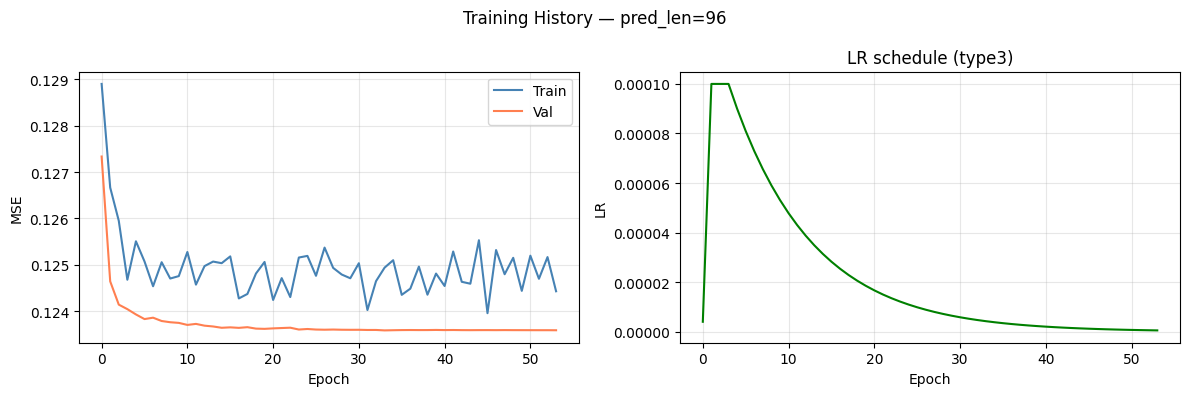

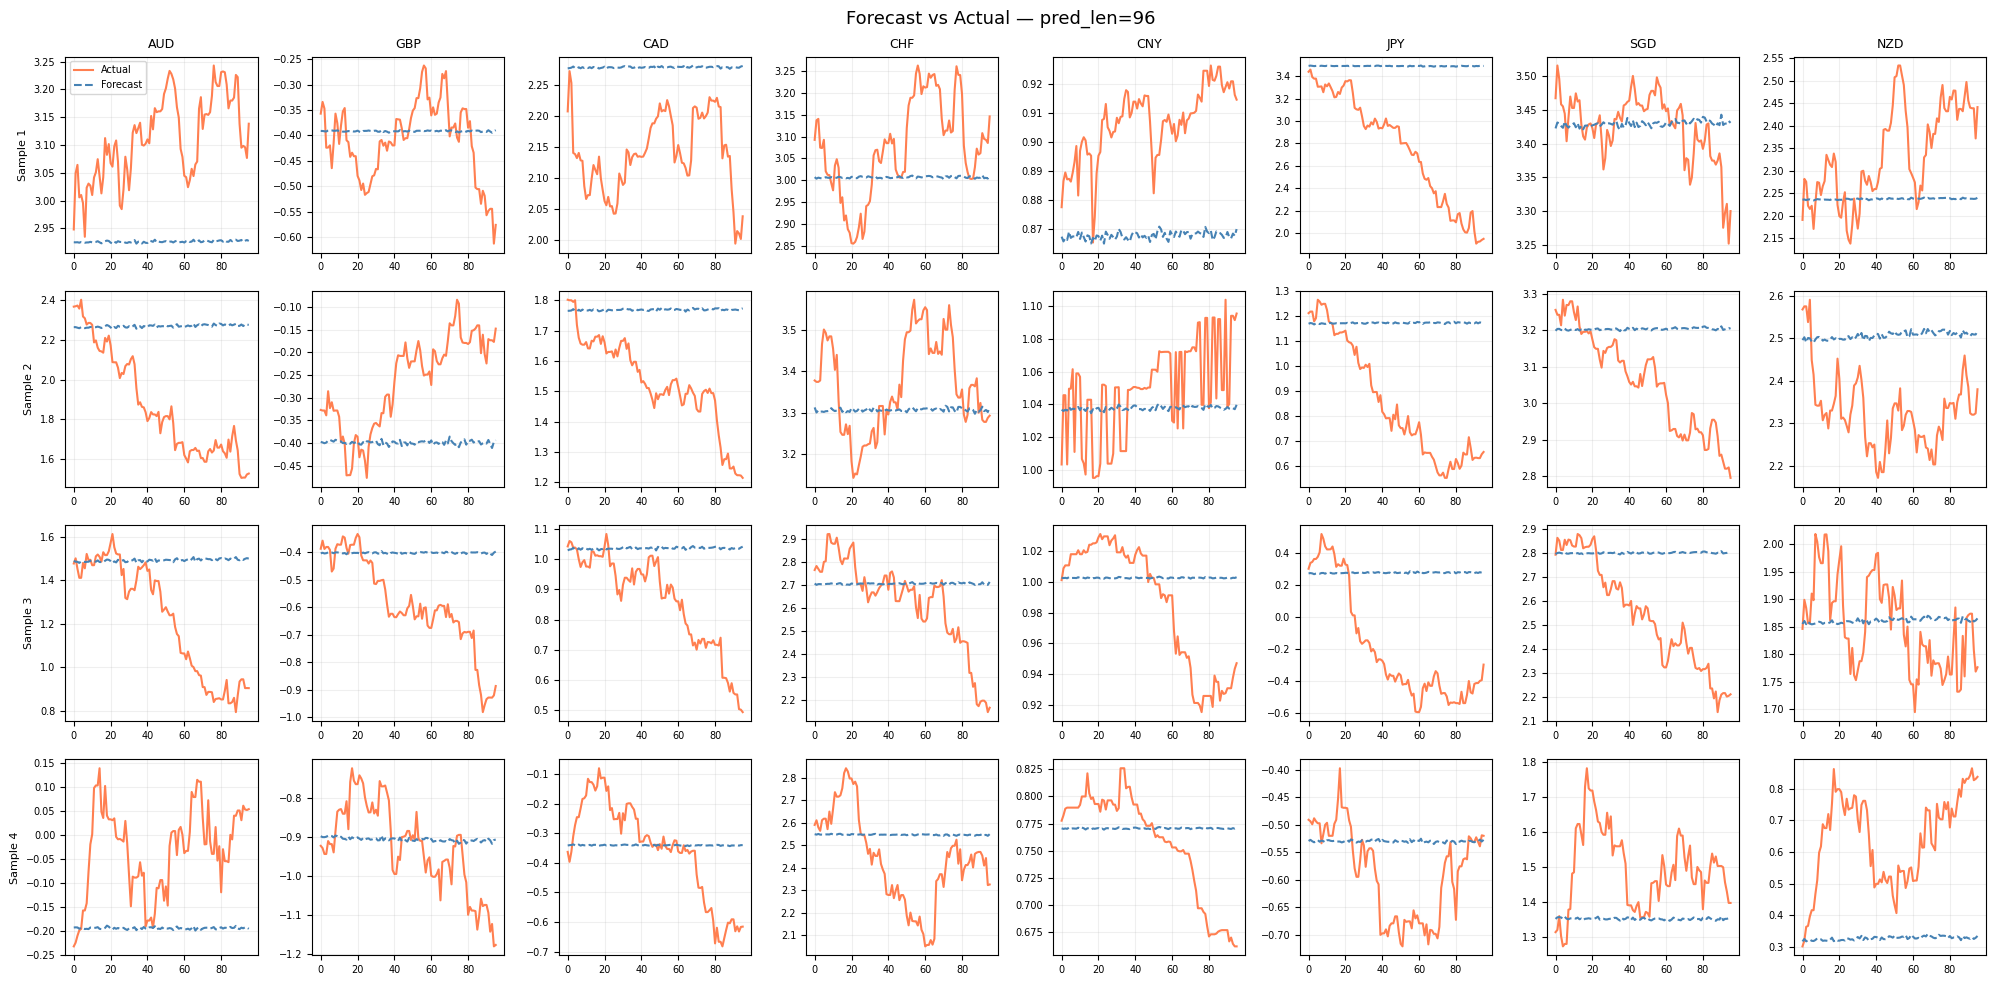

In [ ]:
pred_lens = [96]   # full: [96, 192, 336, 720]

paper_results = {
    96:  {'mse': 0.080, 'mae': 0.196},
    192: {'mse': 0.166, 'mae': 0.288},
    336: {'mse': 0.307, 'mae': 0.398},
    720: {'mse': 0.656, 'mae': 0.582},
}

all_results, all_histories = {}, {}

for pred_len in pred_lens:
    print(f'\n{"="*60}\nRunning pred_len = {pred_len}\n{"="*60}')

    # Exchange.sh batch sizes: 128 for pred_len<=192, 512 for 336/720
    run_cfg = Config(pred_len=pred_len, batch_size=128 if pred_len <= 192 else 512)

    t_loader, v_loader, te_loader, _ = make_loaders(run_cfg)
    run_model = Model(run_cfg).to(run_cfg.device)

    history = train(run_model, t_loader, v_loader, run_cfg)
    all_histories[pred_len] = history

    results = test_model(run_model, te_loader, run_cfg)
    all_results[pred_len] = results

    p = paper_results[pred_len]
    print(f'  MSE: {results["mse"]:.4f}  (paper: {p["mse"]})  diff: {results["mse"]-p["mse"]:+.4f}')
    print(f'  MAE: {results["mae"]:.4f}  (paper: {p["mae"]})  diff: {results["mae"]-p["mae"]:+.4f}')

    plot_training_history(history, pred_len)
    plot_forecasts(results, run_cfg)

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for pl in pred_lens:
    if pl not in all_results: continue
    r, p = all_results[pl], paper_results[pl]
    rows.append({'pred_len': pl,
                 'Ours MSE': round(r['mse'],4), 'Paper MSE': p['mse'],
                 'MSE diff': round(r['mse']-p['mse'],4),
                 'Ours MAE': round(r['mae'],4), 'Paper MAE': p['mae'],
                 'MAE diff': round(r['mae']-p['mae'],4)})
df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

OUT = '/content/drive/MyDrive/2026 Winter STAD68/Project/Results/ModernTCN_scratch/'
os.makedirs(OUT, exist_ok=True)
df_summary.to_csv(OUT + 'results_summary.csv', index=False)
print(f'Saved to {OUT}')

 pred_len  Ours MSE  Paper MSE  MSE diff  Ours MAE  Paper MAE  MAE diff
       96    0.0807       0.08    0.0007    0.1972      0.196    0.0012
Saved to /content/drive/MyDrive/2026 Winter STAD68/Project/Results/ModernTCN_scratch/


---
## Section 7 — KAN Scaffold: Where to Plug In

Now that you've seen the actual architecture, here are the precise substitution points.

### The two FFN branches in `Block.forward()`
```python
# FFN1 (variable-wise): Conv1d(nvars*D, nvars*dff, 1, groups=nvars)
# Equivalent to: Linear(D, dff) applied independently per variable per time position
self.ffn1pw1 = nn.Conv1d(nvars*dmodel, nvars*dff,   1, groups=nvars)
self.ffn1pw2 = nn.Conv1d(nvars*dff,   nvars*dmodel, 1, groups=nvars)

# FFN2 (channel-wise): Conv1d(nvars*D, nvars*dff, 1, groups=dmodel)
# Equivalent to: Linear(M, dff_per_d) applied independently per D channel per time position
self.ffn2pw1 = nn.Conv1d(nvars*dmodel, nvars*dff,   1, groups=dmodel)
self.ffn2pw2 = nn.Conv1d(nvars*dff,   nvars*dmodel, 1, groups=dmodel)
```

### KAN interface contract
A KAN replacement for `ffn1pw1` must:
- Accept `(B, nvars*D, N)` → output `(B, nvars*dff, N)`
- Act independently at each of the N time positions (like kernel_size=1 conv)
- Respect the `groups=nvars` constraint (no cross-variable leakage)

The cleanest approach is to reshape to `(B*N, nvars, D)` and apply KAN per variable,
then reshape back — this avoids fighting the grouped-conv interface.

In [ ]:
class KANLayerStub(nn.Module):
    """
    Placeholder for a Kolmogorov-Arnold Network layer.
    Drop-in replacement for the Conv1d(kernel=1, groups=g) layers in Block's FFN branches.

    Currently a linear fallback (identical behaviour to original).
    Replace internals with efficient-kan or pykan.

    Interface: (B, in_channels, N) → (B, out_channels, N)
    Same as Conv1d(in_channels, out_channels, 1, groups=groups)
    """

    def __init__(self, in_channels: int, out_channels: int, groups: int = 1,
                 grid_size: int = 5):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.groups       = groups
        self.grid_size    = grid_size

        # ── TODO: replace with KAN ────────────────────────────────────────────
        # Option 1 — efficient-kan:
        #   !pip install efficient-kan
        #   from efficient_kan import KANLinear
        #   # Reshape (B, C, N) → (B*N, C//groups, groups), apply KANLinear per group
        #
        # Option 2 — custom B-spline KAN operating on flattened (B*N, in/groups) tensors
        # ─────────────────────────────────────────────────────────────────────
        self._fallback = nn.Conv1d(in_channels, out_channels, 1, groups=groups)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, in_channels, N) → (B, out_channels, N)"""
        return self._fallback(x)


class Block_KAN(Block):
    """
    Block with KAN replacing the FFN1 and/or FFN2 pointwise convolutions.
    Inherits DW conv unchanged — only the pointwise layers are swapped.

    To replace only FFN1: set replace_ffn1=True, replace_ffn2=False
    To replace only FFN2: set replace_ffn1=False, replace_ffn2=True
    To replace both (full KAN block): both=True
    """

    def __init__(self, *args, grid_size: int = 5,
                 replace_ffn1: bool = True, replace_ffn2: bool = True, **kwargs):
        super().__init__(*args, **kwargs)

        nvars  = kwargs.get('nvars') or args[4]
        dmodel = kwargs.get('dmodel') or args[2]
        dff    = self.ffn1pw1.out_channels   # nvars * dff

        if replace_ffn1:
            # Replace FFN1 (variable-wise mixing, groups=nvars)
            self.ffn1pw1 = KANLayerStub(nvars*dmodel, dff,        groups=nvars, grid_size=grid_size)
            self.ffn1pw2 = KANLayerStub(dff,          nvars*dmodel, groups=nvars, grid_size=grid_size)

        if replace_ffn2:
            # Replace FFN2 (channel-wise mixing, groups=dmodel)
            self.ffn2pw1 = KANLayerStub(nvars*dmodel, dff,        groups=dmodel, grid_size=grid_size)
            self.ffn2pw2 = KANLayerStub(dff,          nvars*dmodel, groups=dmodel, grid_size=grid_size)


# ── Verify shapes are preserved ───────────────────────────────────────────────
blk_kan = Block_KAN(51, 5, 64, 64, 8, drop=0.2, grid_size=5,
                    replace_ffn1=True, replace_ffn2=True)
t_out_kan = blk_kan(t_in)
print(f'KAN block output: {t_out_kan.shape}  ← must match {t_in.shape}')

n_orig = sum(p.numel() for p in blk.parameters())
n_kan  = sum(p.numel() for p in blk_kan.parameters())
print(f'Original block params: {n_orig:,}')
print(f'KAN stub block params: {n_kan:,}  (same — stub = linear fallback)')
print('\nNext step: swap KANLayerStub._fallback for a real KANLinear from efficient-kan')

KAN block output: torch.Size([4, 8, 64, 6])  ← must match torch.Size([4, 8, 64, 6])
Original block params: 106,624
KAN stub block params: 106,624  (same — stub = linear fallback)

Next step: swap KANLayerStub._fallback for a real KANLinear from efficient-kan


### Next Steps

1. **Install efficient-kan** — the most practical implementation:
   ```bash
   !pip install efficient-kan
   ```
   Then in `KANLayerStub.__init__`:
   ```python
   from efficient_kan import KANLinear
   # Reshape (B, C, N) → (B*N, C//groups) then apply KANLinear
   ```

2. **Ablation plan:**
   - `replace_ffn1=True,  replace_ffn2=False` — does variable-wise KAN help?
   - `replace_ffn1=False, replace_ffn2=True`  — does channel-wise KAN help?
   - `replace_ffn1=True,  replace_ffn2=True`  — full KAN block

3. **Cross-scale fusion** — the bigger contribution:
   The `use_multi_scale=True` path in `ModernTCN.__init__` builds `lat_layer`, `smooth_layer`,
   `up_sample_conv` but these are FPN-style lateral connections for multi-stage models.
   For Exchange (1 stage), you'd need a different fusion mechanism.

4. **Fair comparison** — match parameter counts between KAN and linear baselines
   before drawing conclusions.

---
## Section 8 — SHAP Circular Beeswarm (Seasonal, Fig. 12 Style)

Reproduces the polar SHAP visualisation from Fig. 12 of:
> Chen et al. (2025). *An interpretable LAI time series prediction model of
> subtropic forests using a ConvLSTM coupling spatiotemporal attention mechanism
> model.* Ecological Indicators 181, 114437.

### Layout
A **2 × 2 grid** of polar plots, one per season (Spring / Summer / Autumn / Winter).
Each panel contains:

| Element | Meaning |
|---------|---------|
| **Spiral inner bars (petals)** | Uniform blade height; the **bottom radius** decreases clockwise — most important feature at outermost ring, least important at innermost, forming the inward spiral of Fig. 12 |
| **Numbers on petal tips** | Exact mean \|SHAP\| value |
| **Feature labels** around the ring | Currency pair names, ordered clockwise by importance |
| **Dashed circle** | Reference baseline (zero-SHAP radius) |
| **Outer dots (beeswarm)** | Each dot = one test sample; radial position = SHAP value (outward = positive, inward = negative); colour = feature value (red = high, blue = low) |

### How SHAP is computed
- **Explainer:** `shap.GradientExplainer` applied to the trained `Model` wrapper.
- **Background:** 50 randomly sampled training inputs (standard practice for GradientExplainer).
- **Input shape to SHAP:** `(B, seq_len=6, 8)`.  
  SHAP returns values of the same shape; we **sum over the time dimension** to get a
  single `(B, 8)` attribution matrix — this collapses the look-back window into a
  per-variable importance score, matching the paper's treatment.
- **Seasonal split:** each test sample is assigned a season based on where its
  window falls in the raw date column of the CSV (March–May = Spring, etc.).


Building data loaders …
Instantiating model …
  Re-used weights from the previously trained run_model.
Computing SHAP values (GradientExplainer) …
  Processed 256/300 samples  (batch shape after normalise: (6, 256, 8, 8)) …
  Processed 300/300 samples  (batch shape after normalise: (6, 44, 8, 8)) …
  shap_4d shape: (6, 300, 8, 8)  ← expect (n_out, N, seq_len, 8)
SHAP matrix shape: (300, 8)  ← must be (N, 8)
Season counts: {'Spring': 75, 'Summer': 88, 'Autumn': 76, 'Winter': 61}
Rendering spiral SHAP plot  [Blue–Red] …


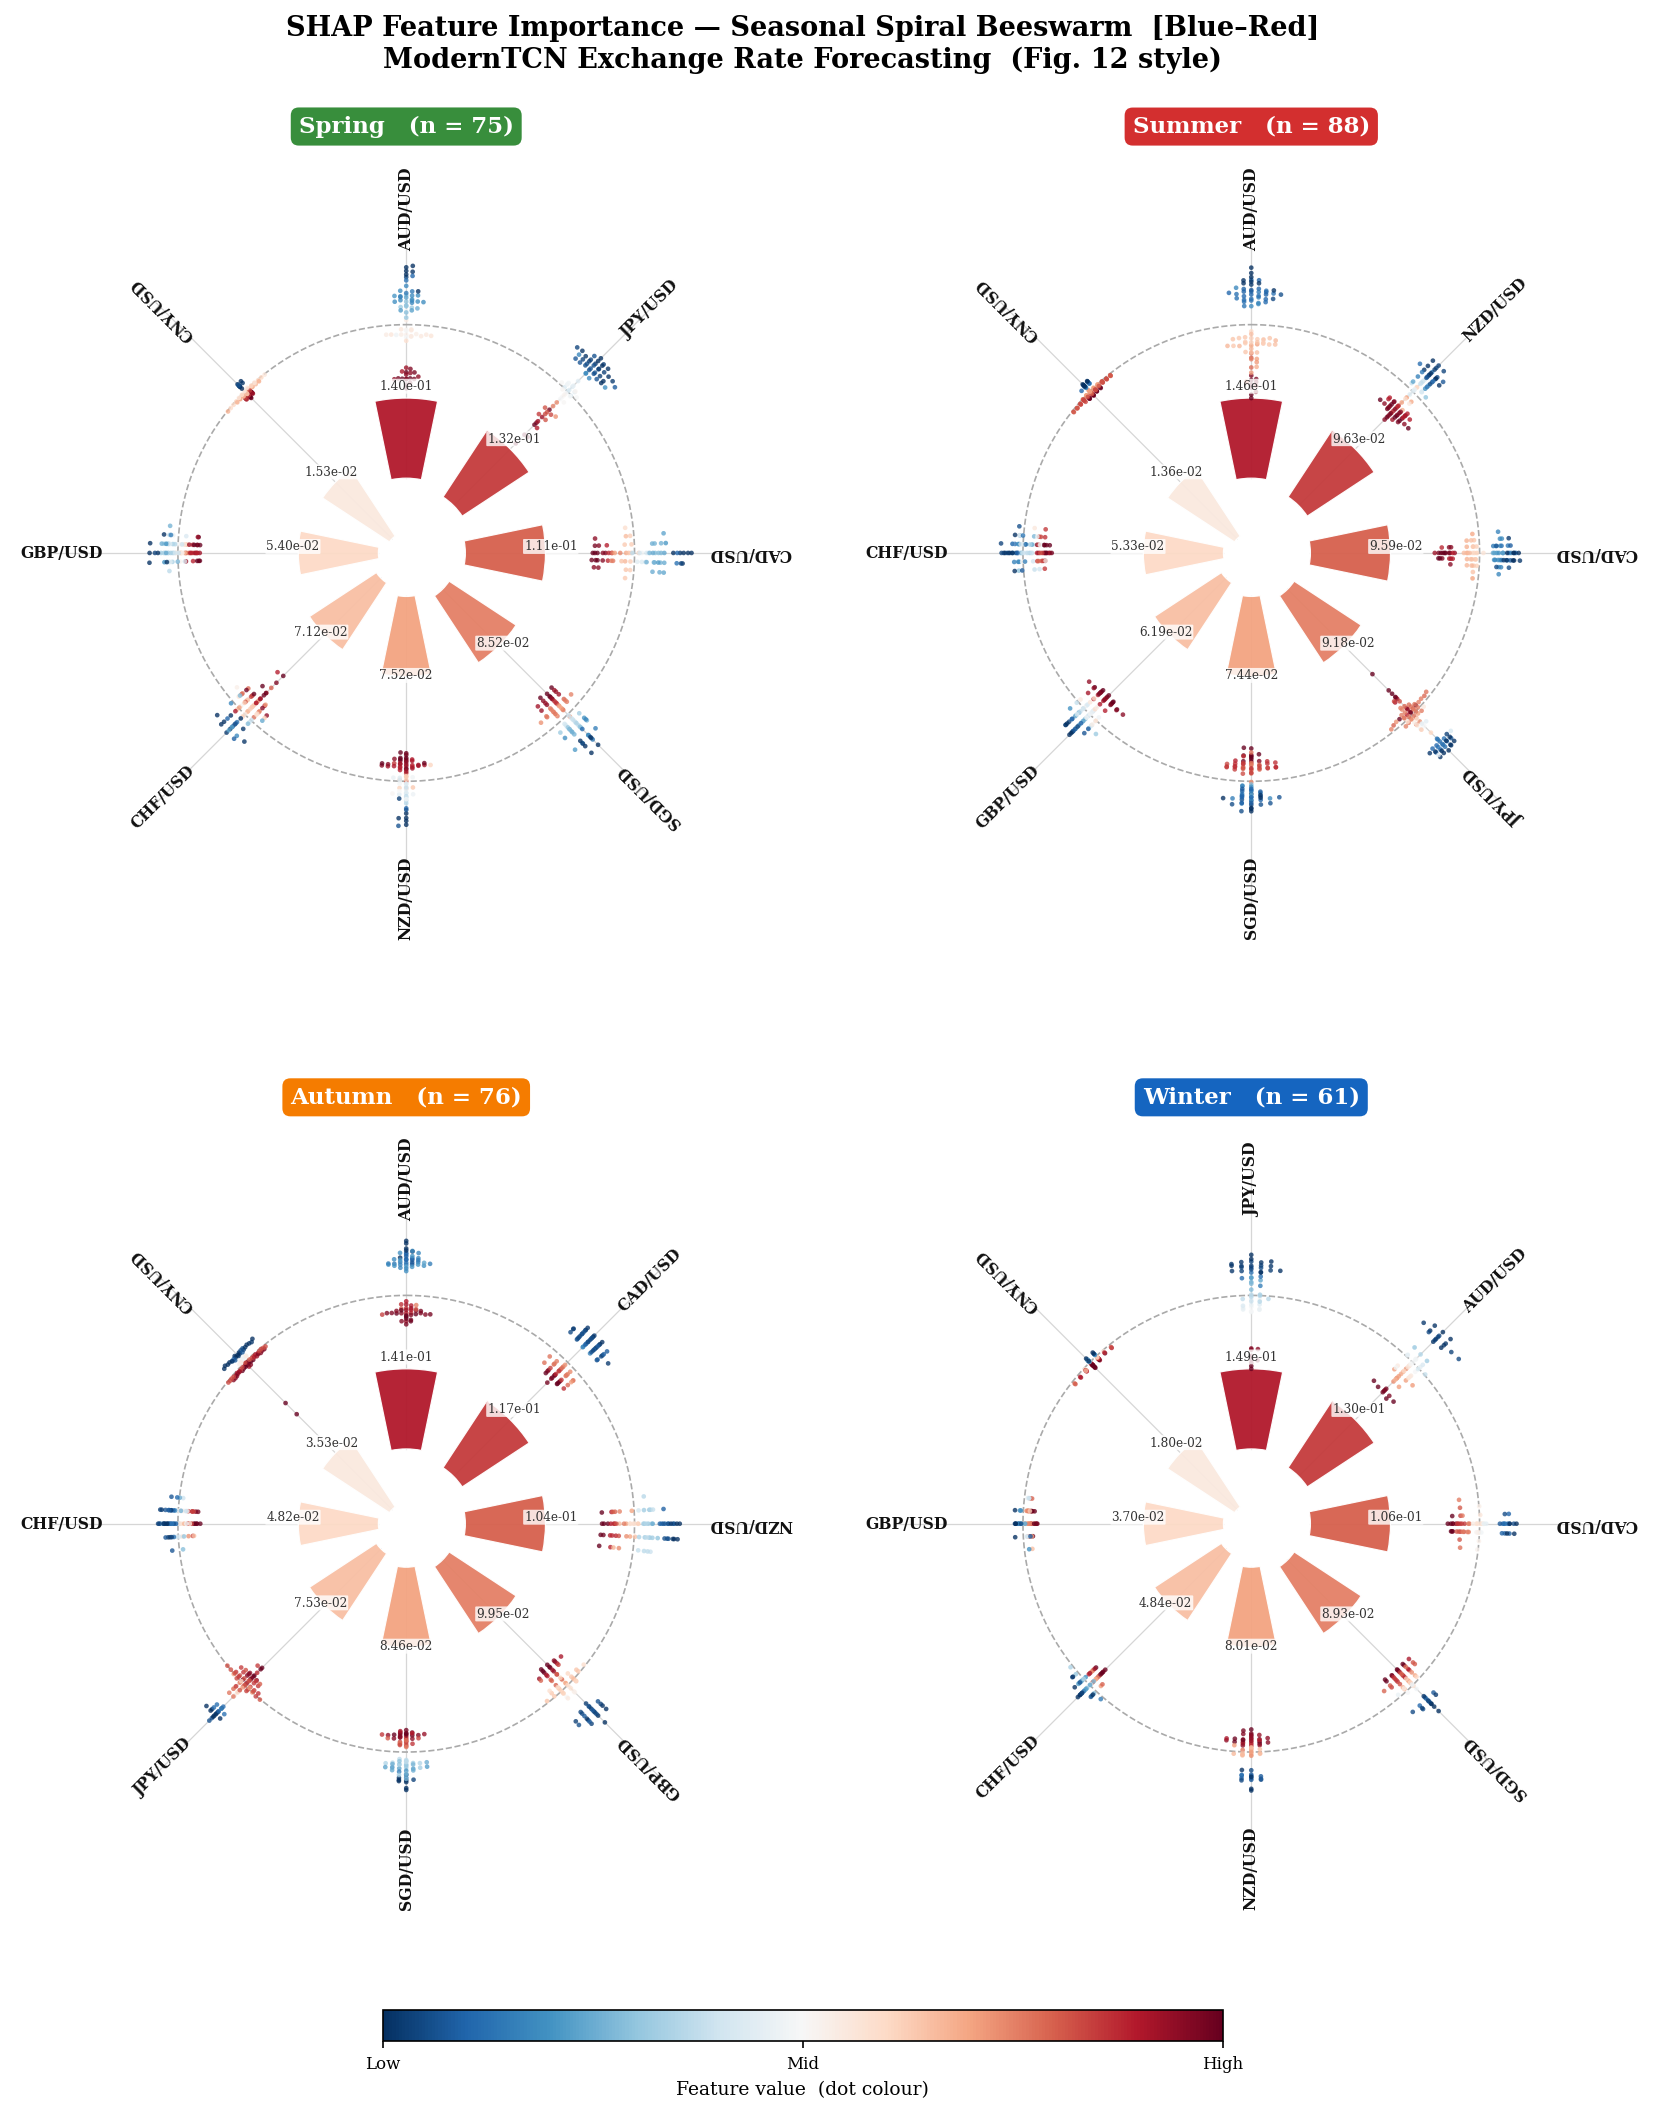

Saved → shap_seasonal_spiral.png  [Blue–Red]


In [ ]:

# ── Install shap if needed ────────────────────────────────────────────────────
# !pip install shap --quiet

from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import shap

# ─────────────────────────────────────────────────────────────────────────────
# 0.  Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
SHAP_BG_SAMPLES  = 50     # background samples for GradientExplainer

# =========================================================
# === Change this to switch sample size
# SHAP_EVAL_SAMPLES = None  # None = use ALL training samples (~7 k)
SHAP_EVAL_SAMPLES = 300
# =========================================================

PRED_LEN_FOR_SHAP = 96    # which trained model to reuse

FEATURE_NAMES = ["AUD/USD", "GBP/USD", "CAD/USD", "CHF/USD",
                 "CNY/USD", "JPY/USD", "SGD/USD", "NZD/USD"]
SEASON_NAMES  = ["Spring", "Summer", "Autumn", "Winter"]
SEASON_MONTHS = {0: [3,4,5], 1: [6,7,8], 2: [9,10,11], 3: [12,1,2]}

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 10,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "axes.unicode_minus": False,
})

# ─────────────────────────────────────────────────────────────────────────────
# 1.  Rebuild dataset and model
# ─────────────────────────────────────────────────────────────────────────────
print("Building data loaders …")
shap_cfg = Config(pred_len=PRED_LEN_FOR_SHAP,
                  batch_size=128 if PRED_LEN_FOR_SHAP <= 192 else 512)
t_loader_sh, _, te_loader_sh, _ = make_loaders(shap_cfg)

print("Instantiating model …")
shap_model = Model(shap_cfg).to(shap_cfg.device)

if 'run_model' in dir() and hasattr(run_model, 'model'):
    try:
        shap_model.load_state_dict(run_model.state_dict())
        print("  Re-used weights from the previously trained run_model.")
    except Exception:
        print("  Training a fresh model for SHAP …")
        train(shap_model, t_loader_sh, _, shap_cfg)
else:
    print("  Training a fresh model for SHAP (run Section 6 first to save time) …")
    train(shap_model, t_loader_sh, _, shap_cfg)

shap_model.eval()

# ─────────────────────────────────────────────────────────────────────────────
# 2.  Collect TRAINING-SET inputs and dates
#     Using the full training set (~7 k samples) gives richer SHAP attribution
#     and enough samples per season for a meaningful beeswarm.
# ─────────────────────────────────────────────────────────────────────────────
print("Collecting training inputs …")
# =========================================================
# === Change this to switch dataset
# train_ds = Dataset_Exchange(shap_cfg, 'train')
train_ds = Dataset_Exchange(shap_cfg, 'test')
# =========================================================

df_dates = pd.read_csv(shap_cfg.data_path, usecols=["date"])
df_dates["date"] = pd.to_datetime(df_dates["date"])

n_train = len(train_ds)
if SHAP_EVAL_SAMPLES is not None:
    idx_eval = np.random.default_rng(42).choice(n_train,
                   min(SHAP_EVAL_SAMPLES, n_train), replace=False)
    idx_eval = np.sort(idx_eval)
else:
    idx_eval = np.arange(n_train)

# Stack inputs: (N, seq_len, 8)
X_eval_list = [train_ds[i][0] for i in idx_eval]
X_eval = torch.stack(X_eval_list).to(shap_cfg.device)

# Assign season: training split starts at row 0 of the CSV
n_total   = len(df_dates)
num_test  = int(n_total * 0.2)
num_train_rows = int(n_total * 0.7)
# border1 for train split = 0 (see Dataset_Exchange._read_data)
border1_train = 0

sample_seasons = []
for i in idx_eval:
    centre_row = border1_train + i + shap_cfg.seq_len // 2
    centre_row = min(centre_row, n_total - 1)
    month = df_dates["date"].iloc[centre_row].month
    s = next(s for s, ms in SEASON_MONTHS.items() if month in ms)
    sample_seasons.append(s)
sample_seasons = np.array(sample_seasons)

# Background: 50 random samples from training set
bg_idx  = np.random.default_rng(0).choice(n_train, SHAP_BG_SAMPLES, replace=False)
bg_list = [train_ds[int(i)][0] for i in bg_idx]
X_bg    = torch.stack(bg_list).to(shap_cfg.device)

# ─────────────────────────────────────────────────────────────────────────────
# 3.  Compute SHAP values with GradientExplainer
#
# Root cause of the "all features = AUD/USD" bug:
#   Using a (B,1) scalar output collapses all 8 variables into one attribution
#   channel — GradientExplainer can't distinguish between variables.
#   Fix: output shape (B, 8) by averaging over pred_len only, keeping variables
#   separate.  This gives SHAP shape (N, seq_len, 8) with distinct values per
#   feature column.
# ─────────────────────────────────────────────────────────────────────────────
print("Computing SHAP values (GradientExplainer) …")

class _ShapWrapper(torch.nn.Module):
    """
    Returns (B, 8): mean over the prediction horizon for each of the 8 variables.
    GradientExplainer receives 8 output units and attributes inputs separately
    to each, yielding shap_values shape (8, N, seq_len, 8) — one (N,seq,8)
    attribution matrix per output variable.
    We then sum each output-variable's attribution over the 8 inputs to get
    the self-attribution: how much each input variable contributed to its own
    forecast (and other variables' forecasts).
    """
    def __init__(self, model): super().__init__(); self.m = model
    def forward(self, x):
        # (B, pred_len, 8) → mean over pred_len → (B, 8)
        return self.m(x).mean(dim=1)

shap_wrapper = _ShapWrapper(shap_model).to(shap_cfg.device)
shap_wrapper.eval()

explainer = shap.GradientExplainer(shap_wrapper, X_bg)

# ── Normalise shap_values() output to (n_out, N, seq_len, 8) ─────────────────
# shap.GradientExplainer.shap_values() returns different shapes depending on the
# installed shap version and model output dimensions:
#
#   Version A (list):  list of n_out arrays, each shape (N, seq_len, 8)
#   Version B (array): ndarray (N, seq_len, 8)       ← single-output equivalent
#   Version C (array): ndarray (n_out, N, seq_len, 8)← already stacked
#
# Strategy: avoid batching entirely for small eval sets (≤ 2000 samples).
# For large sets, collect ONE array per sample and stack once at the end.
# This sidesteps all axis-mismatch problems.

def _normalise_shap(raw) -> np.ndarray:
    """
    Convert any shap_values() return format to (n_out, N, seq_len, n_feat).
    Always returns a 4-D array with samples on axis 1.
    """
    if isinstance(raw, list):
        # list of n_out arrays each (N, seq_len, n_feat)
        arr = np.stack([np.asarray(v, float) for v in raw], axis=0)
        # arr: (n_out, N, seq_len, n_feat)
        return arr
    arr = np.asarray(raw, float)
    if arr.ndim == 3:
        # (N, seq_len, n_feat) → (1, N, seq_len, n_feat)
        return arr[np.newaxis]
    if arr.ndim == 4:
        # could be (n_out, N, seq_len, n_feat) or (N, n_out, seq_len, n_feat)
        # Heuristic: if first dim == 8 and second dim != 8, it is n_out-first
        n_feat = arr.shape[-1]
        if arr.shape[0] == n_feat and arr.shape[1] != n_feat:
            return arr   # (n_out, N, seq_len, n_feat) — already correct
        else:
            # (N, n_out, seq_len, n_feat) → transpose
            return arr.transpose(1, 0, 2, 3)
    raise ValueError(f"Unexpected shap_values shape: {arr.shape}")

# Process in small batches to avoid GPU OOM
SHAP_BATCH = 256
shap_parts = []   # will hold (n_out, batch_i, seq_len, 8) arrays

for start in range(0, len(X_eval), SHAP_BATCH):
    end        = min(start + SHAP_BATCH, len(X_eval))
    raw        = explainer.shap_values(X_eval[start:end])
    part       = _normalise_shap(raw)   # (n_out, batch_i, seq_len, 8)
    shap_parts.append(part)
    print(f"  Processed {end}/{len(X_eval)} samples  "
          f"(batch shape after normalise: {part.shape}) …")

# Stack all batches along the sample axis (axis=1)
# Every element of shap_parts is (n_out, batch_i, seq_len, 8),
# so np.concatenate on axis=1 gives (n_out, N, seq_len, 8).
shap_4d = np.concatenate(shap_parts, axis=1)
print(f"  shap_4d shape: {shap_4d.shape}  ← expect (n_out, N, seq_len, 8)")

# Sum over output-variable axis (0) and time-step axis (2) → (N, 8)
shap_2d = shap_4d.sum(axis=(0, 2))   # (N, 8)

# Feature values for colouring dots: mean over look-back window → (N, 8)
feat_2d = X_eval.detach().cpu().numpy().mean(axis=1)   # (N, 8)

print(f"SHAP matrix shape: {shap_2d.shape}  ← must be (N, 8)")
s_counts = {SEASON_NAMES[s]: int((sample_seasons==s).sum()) for s in range(4)}
print(f"Season counts: {s_counts}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  Helper functions
# ─────────────────────────────────────────────────────────────────────────────

def _scale01(v: np.ndarray, q_lo=5.0, q_hi=95.0) -> np.ndarray:
    """Normalise to [0,1] using percentile clipping."""
    v = np.asarray(v, float)
    lo, hi = np.nanpercentile(v, [q_lo, q_hi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.full_like(v, 0.5)
    return (np.clip(v, lo, hi) - lo) / (hi - lo)

def _beeswarm_angular_offsets(shap_vals: np.ndarray, nbins=40,
                               spacing=1.0) -> np.ndarray:
    """Compute beeswarm stacking offsets along the angular axis."""
    offs = np.zeros(len(shap_vals), float)
    finite = np.isfinite(shap_vals)
    if not np.any(finite):
        return offs
    v = shap_vals[finite]
    if np.allclose(v.min(), v.max()):
        return offs
    edges  = np.linspace(v.min(), v.max(), nbins + 1)
    bin_id = np.clip(np.digitize(v, edges, right=False) - 1, 0, nbins - 1)
    f_idx  = np.flatnonzero(finite)
    for b in range(nbins):
        slot = f_idx[np.flatnonzero(bin_id == b)]
        for k, ii in enumerate(slot):
            step = (k + 1) // 2
            sign = 1.0 if (k % 2 == 1) else -1.0
            offs[ii] = 0.0 if k == 0 else sign * step * spacing
    return offs

# ─────────────────────────────────────────────────────────────────────────────
# 5.  Draw the 2×2 seasonal spiral polar plot (Fig. 12 style)
#
# Three colour schemes — set COLOUR_SCHEME to 0, 1, or 2:
#   0 → Blue–Red     (RdBu_r)  — matches reference Image 1
#   1 → Cyan–Brown   (BrBG_r)  — matches reference Image 2
#   2 → Purple–Green (PRGn_r)  — matches reference Image 3
#
# The SAME colourmap is used for petals and dots:
#   • Petals: sampled from the dark end (rank 0 = darkest, rank m-1 = palest)
#   • Dots:   feature value (low→high) mapped through the full cmap
# ─────────────────────────────────────────────────────────────────────────────

# ── Select colour scheme ──────────────────────────────────────────────────────
COLOUR_SCHEME = 0   # 0 = Blue–Red | 1 = Cyan–Brown | 2 = Purple–Green

_SCHEMES = [
    ("Blue–Red",      "RdBu_r",  "RdBu_r"),
    ("Cyan–Brown",    "BrBG_r",  "BrBG_r"),
    ("Purple–Green",  "PRGn_r",  "PRGn_r"),
]
_scheme_name, _petal_cmap_name, _dot_cmap_name = _SCHEMES[COLOUR_SCHEME]
petal_cmap = mpl.colormaps.get_cmap(_petal_cmap_name)
dot_cmap   = mpl.colormaps.get_cmap(_dot_cmap_name)

# ── Geometry constants ────────────────────────────────────────────────────────
SPIRAL_OUTER_R = 0.56    # bottom of most-important petal
SPIRAL_INNER_R = 0.15    # bottom of least-important petal
PETAL_HEIGHT   = 0.6    # uniform blade height
PETAL_WIDTH_FR = 0.52    # bar width as fraction of sector
SWARM_R0       = SPIRAL_OUTER_R + PETAL_HEIGHT + 0.55   # beeswarm reference circle
SWARM_SCALE    = 0.55    # radial spread of dot cloud
THETA_SPREAD   = 0.28    # angular jitter fraction of bar width
LABEL_R_PAD    = 0.32    # extra gap beyond outermost dot for feature labels

print(f"Rendering spiral SHAP plot  [{_scheme_name}] …")

fig = plt.figure(figsize=(14, 14), facecolor="white")
fig.suptitle(
    f"SHAP Feature Importance — Seasonal Spiral Beeswarm  [{_scheme_name}]\n"
    "ModernTCN Exchange Rate Forecasting  (Fig. 12 style)",
    fontsize=13, fontweight="bold", y=0.98
)
season_title_colors = ["#388E3C", "#D32F2F", "#F57C00", "#1565C0"]

for s_idx in range(4):
    ax = fig.add_subplot(2, 2, s_idx + 1, projection="polar")

    mask = (sample_seasons == s_idx)
    if mask.sum() < 3:
        ax.set_title(f"{SEASON_NAMES[s_idx]}\n(n < 3, skipped)", color="grey", fontsize=11)
        continue

    sv  = shap_2d[mask]
    fv  = feat_2d[mask]
    n_s = mask.sum()

    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)[::-1]
    m        = len(order)
    sv_ord   = sv[:, order]
    fv_ord   = fv[:, order]
    ma_ord   = mean_abs[order]
    lbl_ord  = [FEATURE_NAMES[int(i)] for i in order]

    theta = np.linspace(0.0, 2.0 * np.pi, m, endpoint=False)
    width = 2.0 * np.pi / m * PETAL_WIDTH_FR

    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.set_xticklabels([])
    ax.set_rticks([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.spines["polar"].set_visible(False)

    # ── 5a.  Spiral petals ────────────────────────────────────────────────────
    bottoms    = np.linspace(SPIRAL_OUTER_R, SPIRAL_INNER_R, m) if m > 1                  else np.array([SPIRAL_OUTER_R])
    petal_t    = np.linspace(0.90, 0.55, m)    # dark→pale along spiral
    bar_colors = petal_cmap(petal_t)

    ax.bar(theta, PETAL_HEIGHT, width=width, bottom=bottoms,
           color=bar_colors, edgecolor="white", linewidth=0.6,
           alpha=0.95, zorder=3)

    # ── 5b.  Spoke lines ──────────────────────────────────────────────────────
    r_spoke_end = SWARM_R0 + SWARM_SCALE + LABEL_R_PAD + 0.08
    for th, bot in zip(theta, bottoms):
        ax.plot([th, th], [bot, r_spoke_end],
                color="#cccccc", linewidth=0.6, zorder=1, alpha=0.8)

    # ── 5c.  Value labels at petal tip ────────────────────────────────────────
    for th, bot, val in zip(theta, bottoms, ma_ord):
        ax.text(th, bot + PETAL_HEIGHT + 0.04, f"{float(val):.2e}",
                ha="center", va="bottom", fontsize=5.8, color="#333333", zorder=7,
                bbox=dict(boxstyle="round,pad=0.08", fc="white", ec="none", alpha=0.80))

    # ── 5d.  Beeswarm reference circle ────────────────────────────────────────
    circ_t = np.linspace(0.0, 2.0 * np.pi, 720)
    ax.plot(circ_t, np.full_like(circ_t, SWARM_R0),
            "--", color="#aaaaaa", lw=0.8, zorder=2)

    # ── 5e.  Beeswarm dots ────────────────────────────────────────────────────
    abs_max = float(np.abs(sv_ord).max()) or 1.0

    for i in range(m):
        si      = sv_ord[:, i]
        fi      = fv_ord[:, i]
        colors  = dot_cmap(_scale01(fi))
        offsets = _beeswarm_angular_offsets(si)
        max_off = float(np.max(np.abs(offsets))) or 1.0
        dtheta  = (offsets / max_off) * (width * THETA_SPREAD)
        r  = SWARM_R0 + (si / abs_max) * SWARM_SCALE
        th = theta[i] + dtheta
        ax.scatter(th, r, s=5, c=colors, alpha=0.78,
                   linewidths=0, zorder=5, rasterized=True)

    # ── 5f.  Feature labels — OUTSIDE the beeswarm dots ──────────────────────
    # Placed beyond SWARM_R0 + SWARM_SCALE so they never overlap the dot cloud.
    r_label = SWARM_R0 + SWARM_SCALE + LABEL_R_PAD
    for th, lbl in zip(theta, lbl_ord):
        deg = np.degrees(th) % 360
        rot = -(deg - 90) + (180 if 85 < deg < 275 else 0)
        ax.text(th, r_label, lbl,
                ha="center", va="center", fontsize=7.5, fontweight="bold",
                rotation=rot, rotation_mode="anchor",
                color="#111111", zorder=8)

    ax.set_rlim(0, r_label + 0.35)
    ax.set_title(
        f"{SEASON_NAMES[s_idx]}   (n = {n_s:,})",
        fontsize=11, fontweight="bold", color="white", pad=14,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor=season_title_colors[s_idx], edgecolor="none")
    )

# ── Shared colourbar ──────────────────────────────────────────────────────────
norm_cb = mpl.colors.Normalize(vmin=0, vmax=1)
sm_cb   = mpl.cm.ScalarMappable(cmap=dot_cmap, norm=norm_cb)
sm_cb.set_array([])
cbar_ax = fig.add_axes([0.30, 0.015, 0.40, 0.015])
cb = fig.colorbar(sm_cb, cax=cbar_ax, orientation="horizontal")
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(["Low", "Mid", "High"])
cb.set_label("Feature value  (dot colour)", fontsize=9)
cbar_ax.tick_params(labelsize=8)

plt.subplots_adjust(wspace=0.08, hspace=0.12, top=0.93, bottom=0.055)
plt.savefig("shap_seasonal_spiral.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
print(f"Saved → shap_seasonal_spiral.png  [{_scheme_name}]")


Rendering [Blue–Red] → shap_spiral_Blue–Red.png …


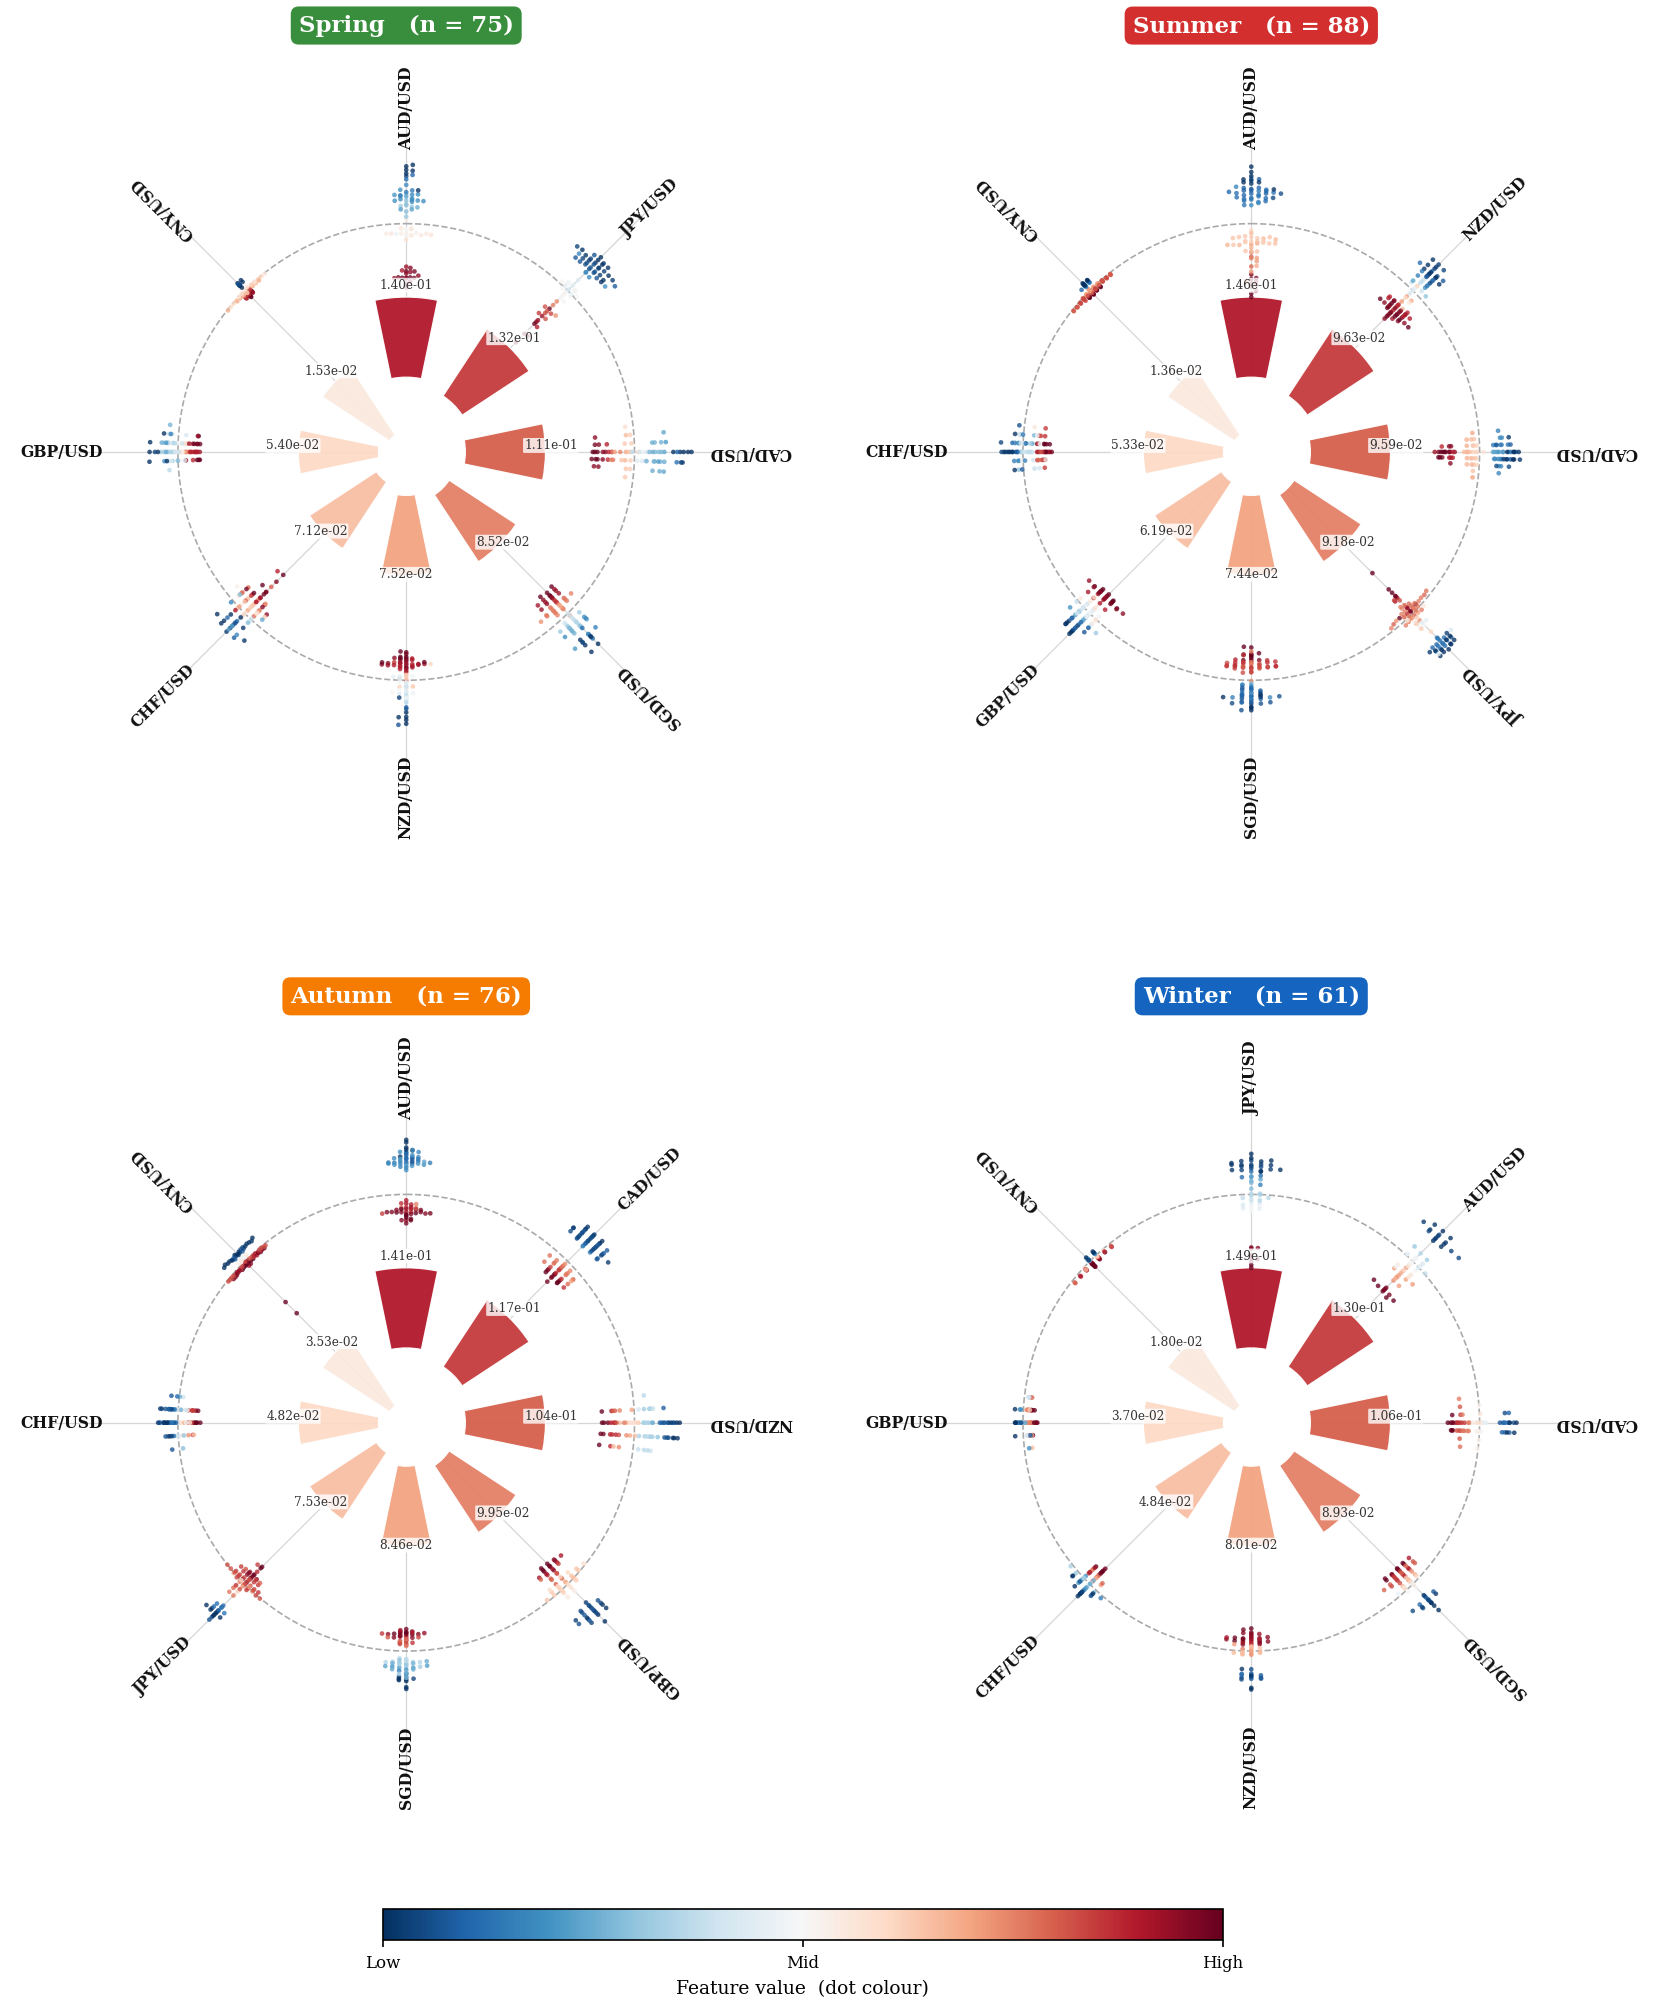

  Saved → shap_spiral_Blue–Red.png
Rendering [Cyan–Brown] → shap_spiral_Cyan–Brown.png …


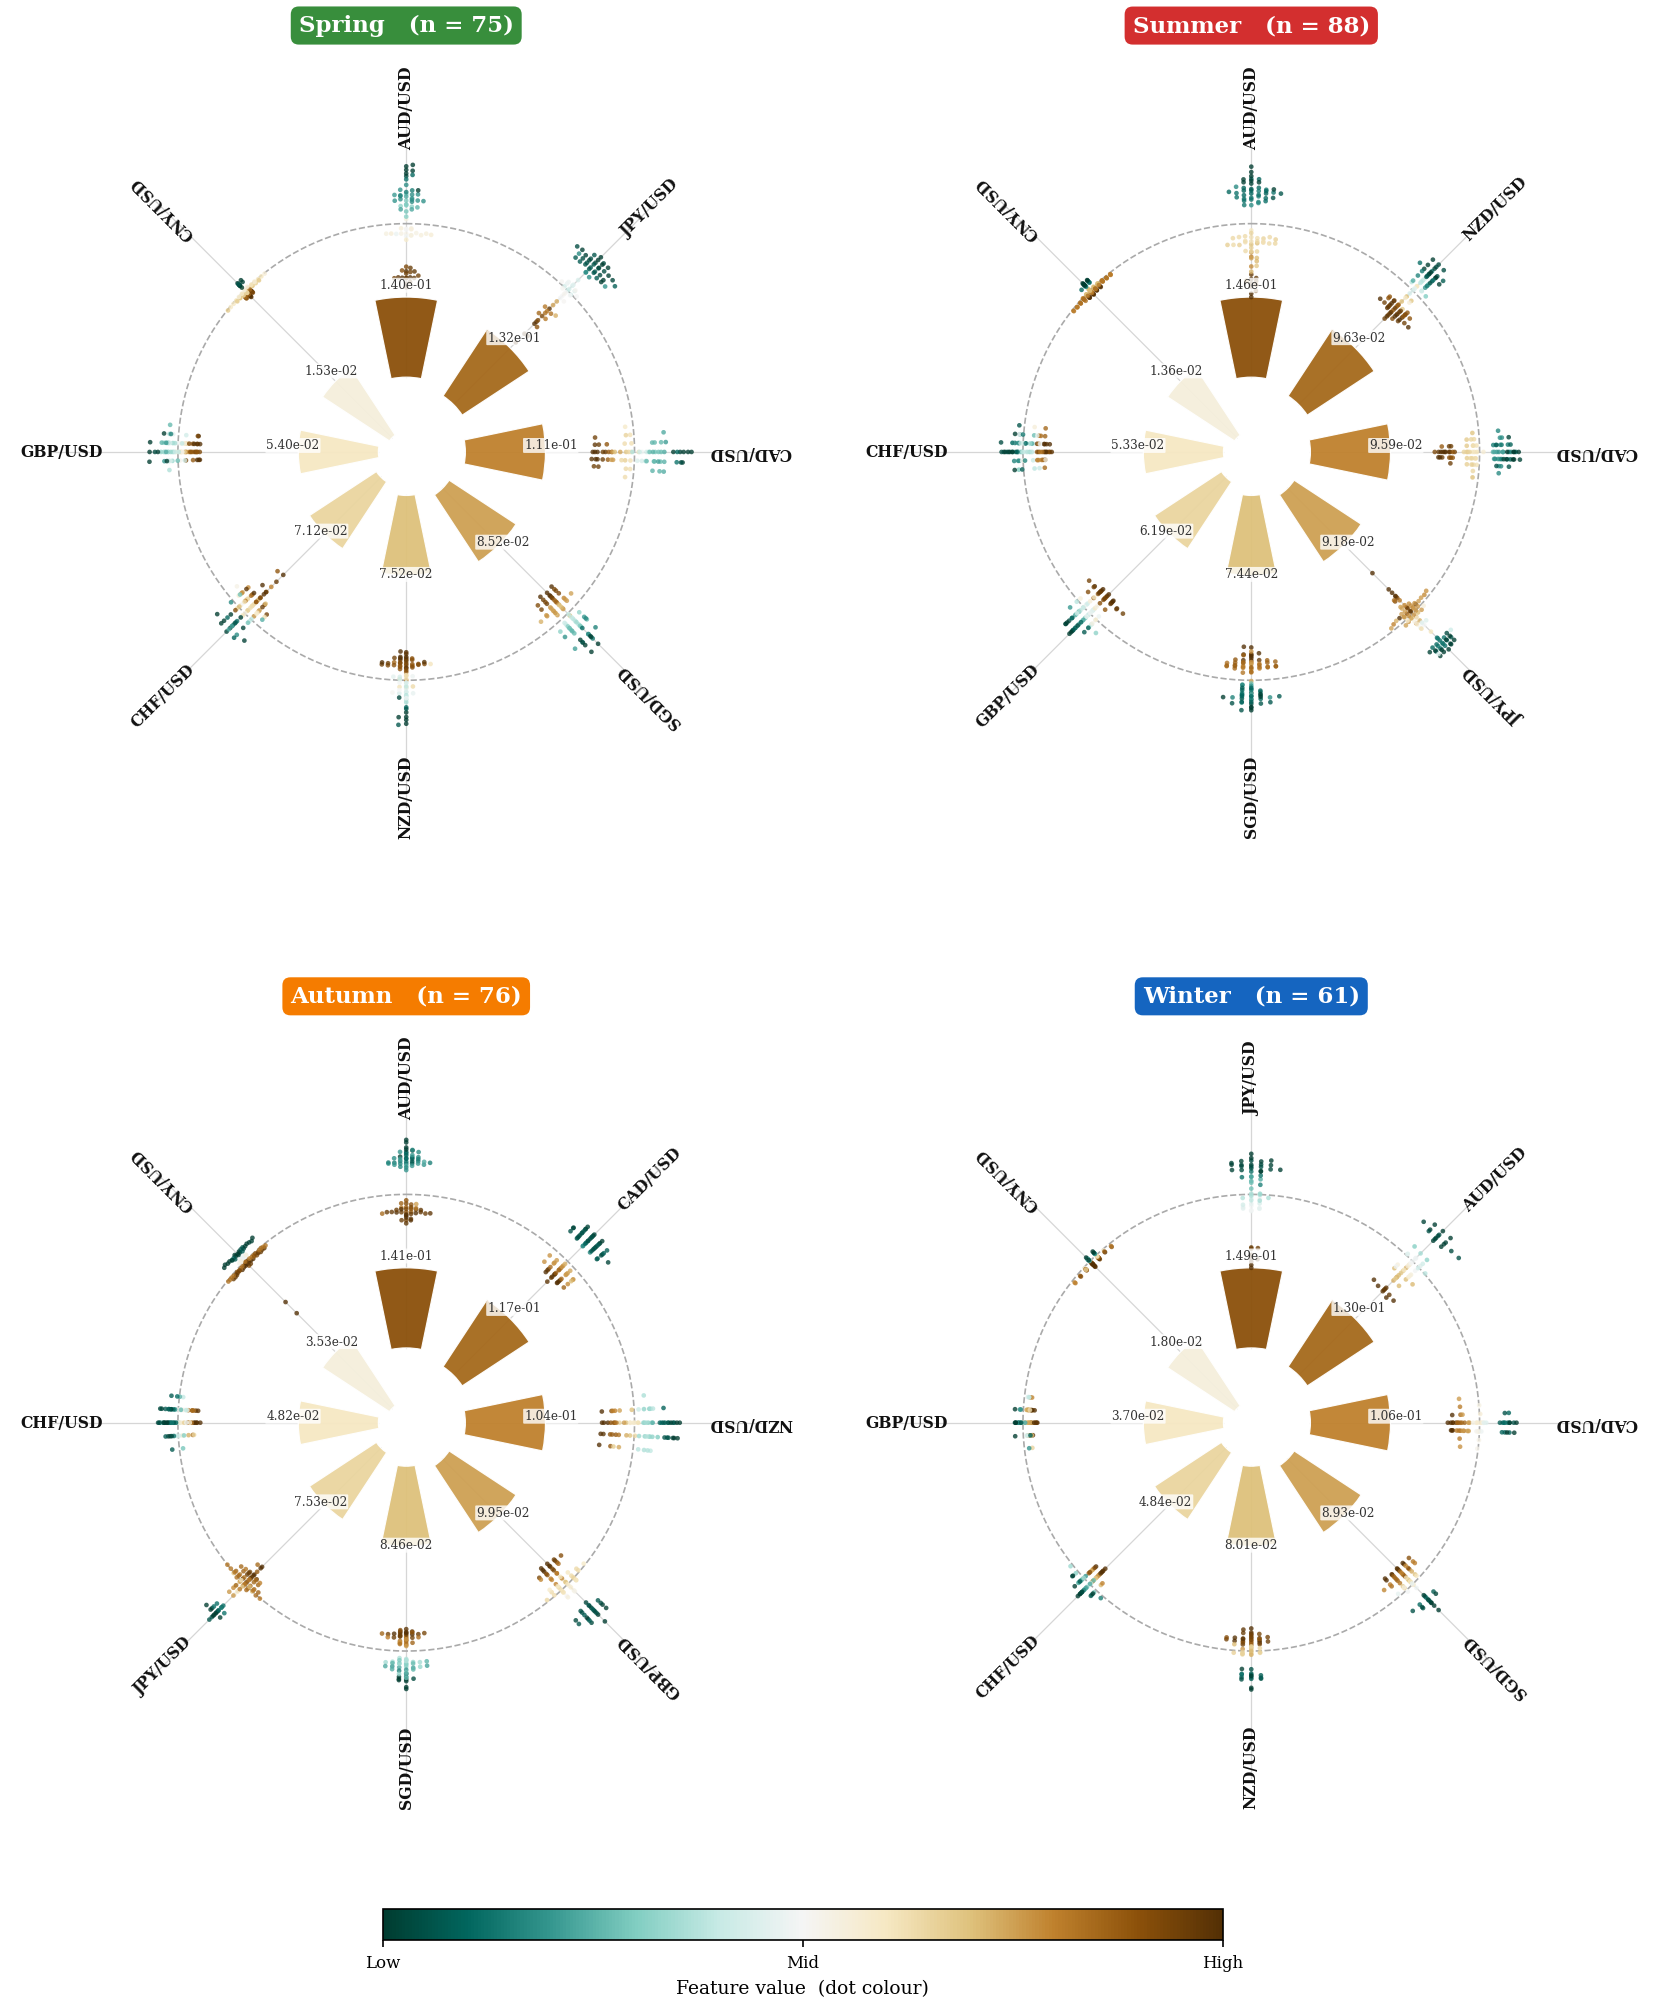

  Saved → shap_spiral_Cyan–Brown.png
Rendering [Purple–Green] → shap_spiral_Purple–Green.png …


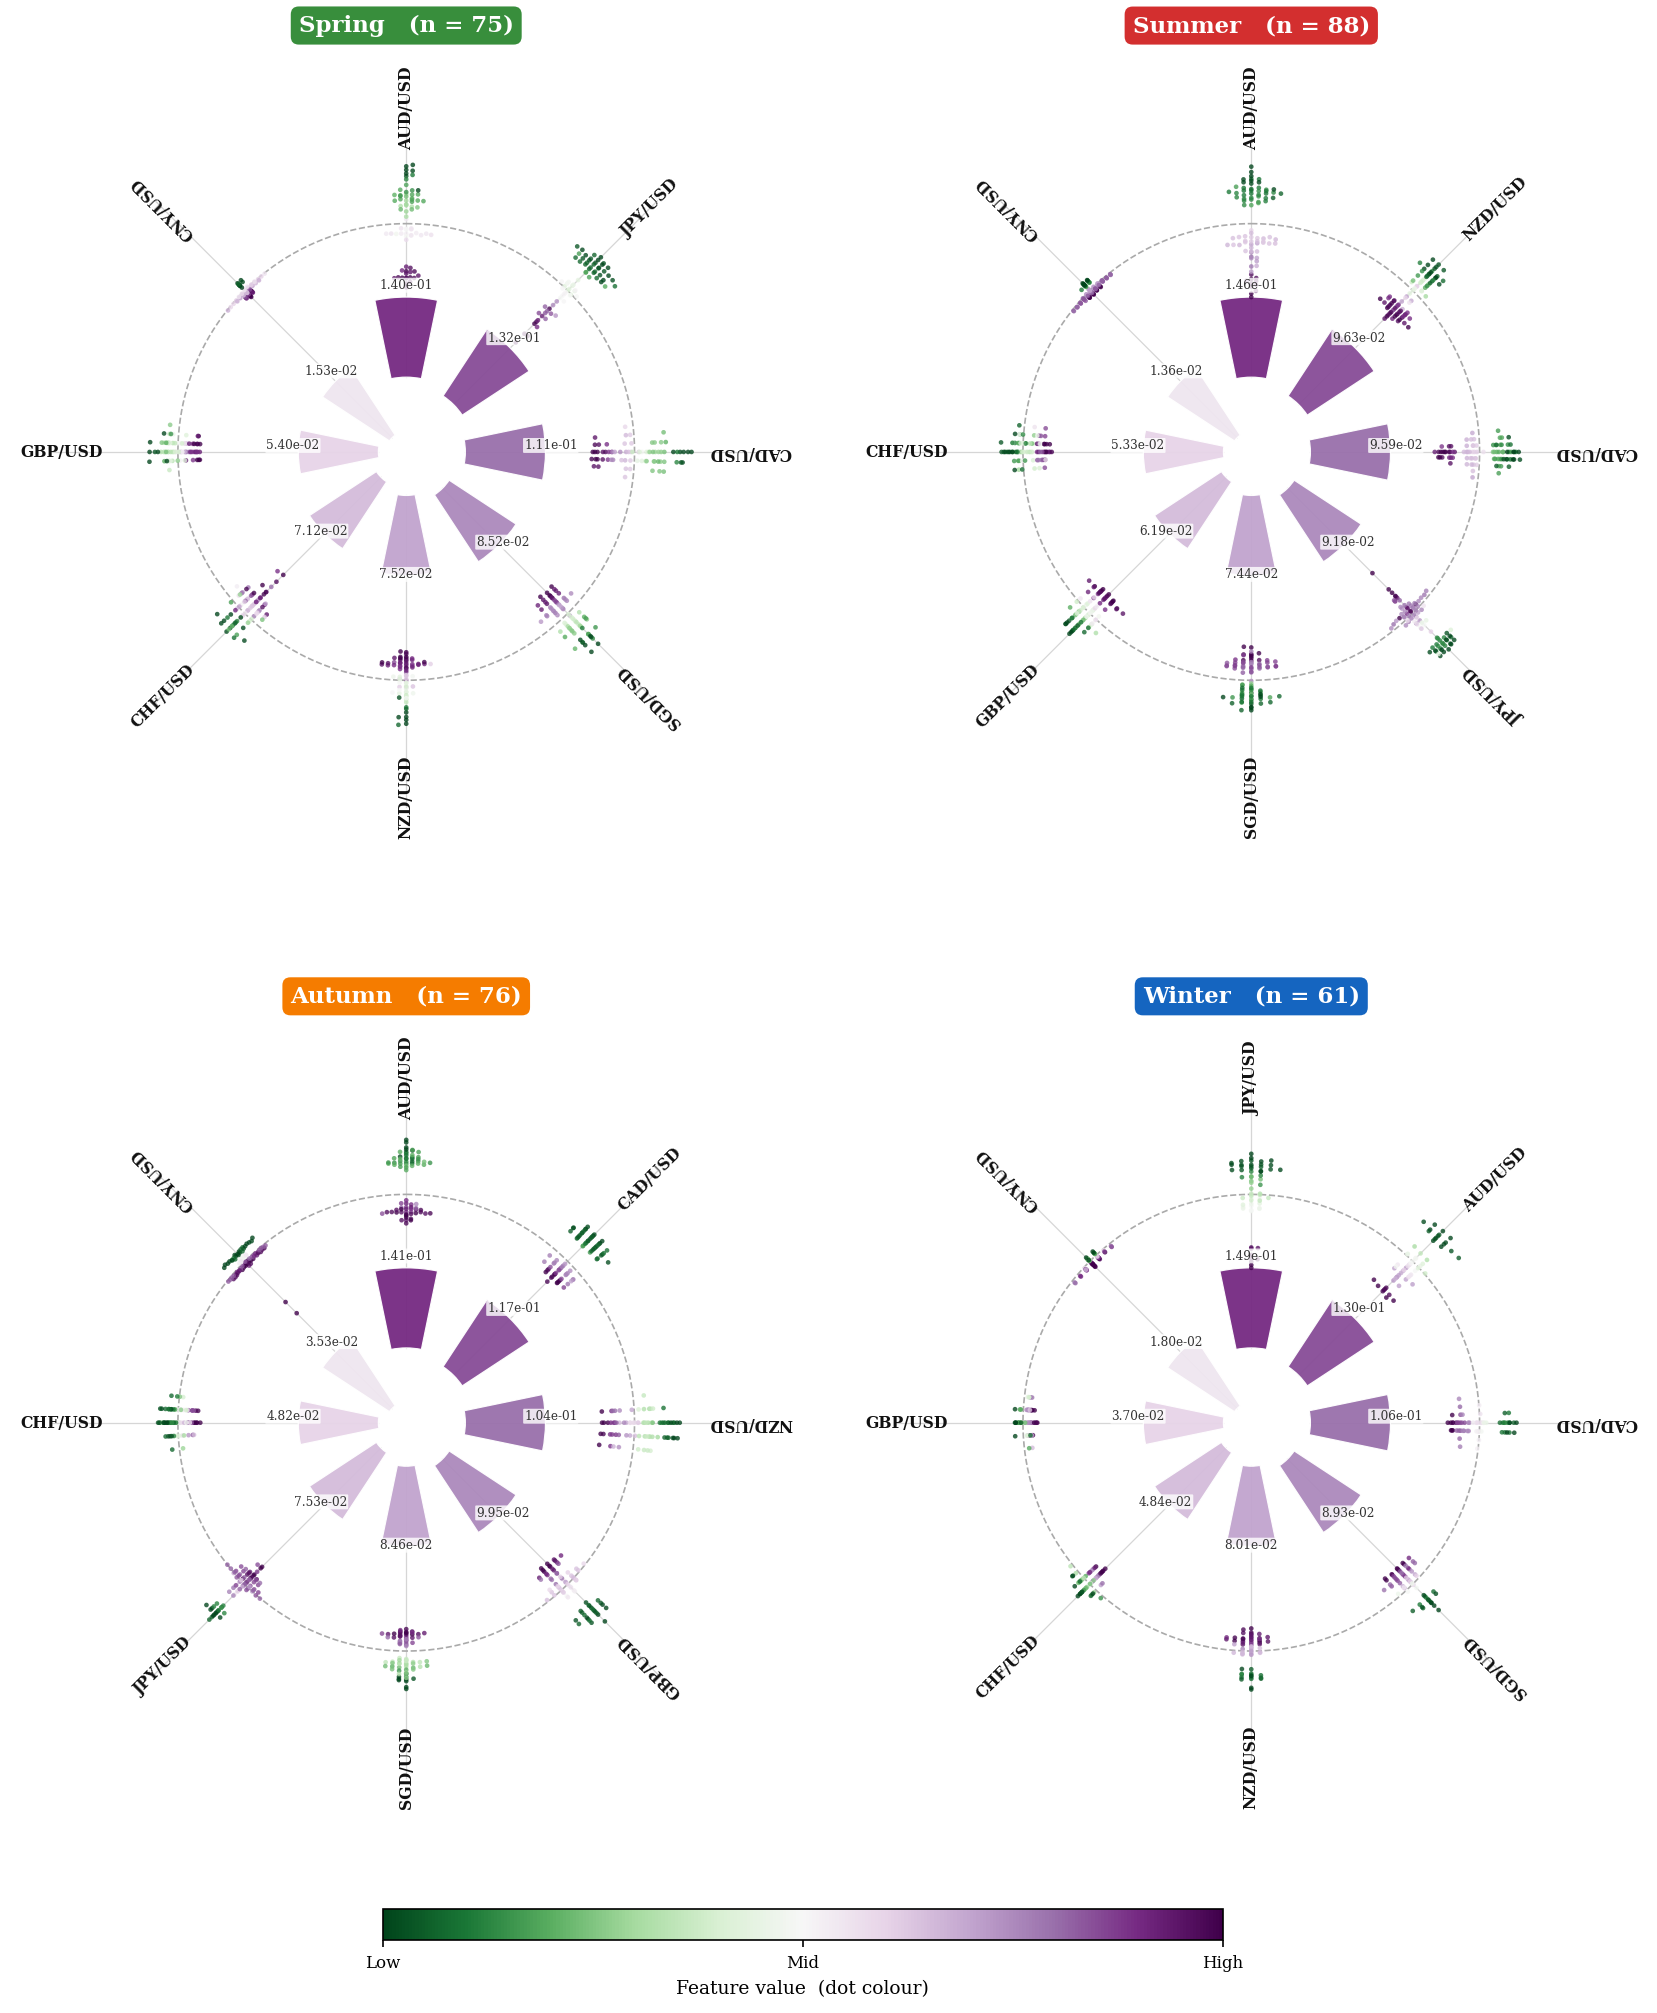

  Saved → shap_spiral_Purple–Green.png


In [ ]:
def draw_spiral_shap_v2(shap_2d, feat_2d, sample_seasons,
                     scheme_idx: int = 0,
                     save_as: str | None = None):
    """
    Render the 2×2 seasonal spiral SHAP beeswarm using in-memory arrays.

    Parameters
    ----------
    shap_2d        : (N, 8) SHAP attributions  — already computed
    feat_2d        : (N, 8) raw feature values  — already computed
    sample_seasons : (N,)   integer 0-3
    scheme_idx     : 0 = Blue-Red | 1 = Cyan-Brown | 2 = Purple-Green
    save_as        : filename to save (None = auto-generated from scheme name)
    """
    scheme_name, petal_cmap_name, dot_cmap_name = _SCHEMES[scheme_idx]
    petal_cmap = mpl.colormaps.get_cmap(petal_cmap_name)
    dot_cmap   = mpl.colormaps.get_cmap(dot_cmap_name)

    swarm_r0 = SPIRAL_OUTER_R + PETAL_HEIGHT + 0.55  # reference circle radius

    if save_as is None:
        save_as = f"shap_spiral_{scheme_name.replace(' ', '_').replace('-','_')}.png"

    print(f"Rendering [{scheme_name}] → {save_as} …")

    fig = plt.figure(figsize=(14, 14), facecolor="white")
    # fig.suptitle(
    #     f"SHAP Feature Importance — Seasonal Spiral Beeswarm  [{scheme_name}]\n"
    #     "ModernTCN Exchange Rate Forecasting  (Fig. 12 style)",
    #     fontsize=13, fontweight="bold", y=0.98
    # )

    for s_idx in range(4):
        ax   = fig.add_subplot(2, 2, s_idx + 1, projection="polar")
        mask = (sample_seasons == s_idx)
        if mask.sum() < 3:
            ax.set_title(f"{SEASON_NAMES[s_idx]}\n(n < 3, skipped)",
                         color="grey", fontsize=11)
            continue

        sv   = shap_2d[mask]; fv = feat_2d[mask]; n_s = mask.sum()
        mean_abs = np.abs(sv).mean(axis=0)
        order    = np.argsort(mean_abs)[::-1];  m = len(order)
        sv_ord   = sv[:, order]; fv_ord = fv[:, order]
        ma_ord   = mean_abs[order]
        lbl_ord  = [FEATURE_NAMES[int(i)] for i in order]

        theta = np.linspace(0.0, 2.0 * np.pi, m, endpoint=False)
        width = 2.0 * np.pi / m * PETAL_WIDTH_FR

        ax.set_theta_direction(-1)
        ax.set_theta_offset(np.pi / 2.0)
        ax.set_xticklabels([]); ax.set_rticks([]); ax.set_yticklabels([])
        ax.grid(False); ax.spines["polar"].set_visible(False)

        # ── Spiral petals ─────────────────────────────────────────────────────
        bottoms    = (np.linspace(SPIRAL_OUTER_R, SPIRAL_INNER_R, m)
                      if m > 1 else np.array([SPIRAL_OUTER_R]))
        petal_t    = np.linspace(0.90, 0.55, m)   # dark→pale along spiral
        bar_colors = petal_cmap(petal_t)
        ax.bar(theta, PETAL_HEIGHT, width=width, bottom=bottoms,
               color=bar_colors, edgecolor="white", linewidth=0.6,
               alpha=0.95, zorder=3)

        # ── Spoke lines: from petal base to beyond label radius ───────────────
        r_spoke_end = swarm_r0 + SWARM_SCALE + LABEL_R_PAD + 0.08
        for th, bot in zip(theta, bottoms):
            ax.plot([th, th], [bot, r_spoke_end],
                    color="#cccccc", linewidth=0.6, zorder=1, alpha=0.8)

        # ── Value labels at petal tip ─────────────────────────────────────────
        for th, bot, val in zip(theta, bottoms, ma_ord):
            ax.text(th, bot + PETAL_HEIGHT + 0.04, f"{float(val):.2e}",
                    ha="center", va="bottom", fontsize=5.8,
                    color="#333333", zorder=7,
                    bbox=dict(boxstyle="round,pad=0.08",
                              fc="white", ec="none", alpha=0.80))

        # ── Beeswarm reference circle ─────────────────────────────────────────
        circ_t = np.linspace(0.0, 2.0 * np.pi, 720)
        ax.plot(circ_t, np.full_like(circ_t, swarm_r0),
                "--", color="#aaaaaa", lw=0.8, zorder=2)

        # ── Beeswarm dots ─────────────────────────────────────────────────────
        abs_max = float(np.abs(sv_ord).max()) or 1.0
        for i in range(m):
            si      = sv_ord[:, i]; fi = fv_ord[:, i]
            colors  = dot_cmap(_scale01(fi))
            offsets = _beeswarm_angular_offsets(si)
            max_off = float(np.max(np.abs(offsets))) or 1.0
            dtheta  = (offsets / max_off) * (width * THETA_SPREAD)
            ax.scatter(theta[i] + dtheta,
                       swarm_r0 + (si / abs_max) * SWARM_SCALE,
                       s=5, c=colors, alpha=0.78, linewidths=0,
                       zorder=5, rasterized=True)

        # ── Feature labels — OUTSIDE beeswarm dots, at end of spoke lines ─────
        r_label = swarm_r0 + SWARM_SCALE + LABEL_R_PAD
        for th, lbl in zip(theta, lbl_ord):
            deg = np.degrees(th) % 360
            rot = -(deg - 90) + (180 if 85 < deg < 275 else 0)
            ax.text(th, r_label, lbl,
                    ha="center", va="center", fontsize=7.5, fontweight="bold",
                    rotation=rot, rotation_mode="anchor",
                    color="#111111", zorder=8)

        ax.set_rlim(0, r_label + 0.35)
        ax.set_title(
            f"{SEASON_NAMES[s_idx]}   (n = {n_s:,})",
            fontsize=11, fontweight="bold", color="white", pad=14,
            bbox=dict(boxstyle="round,pad=0.35",
                      facecolor=season_title_colors[s_idx], edgecolor="none")
        )

    # ── Shared colourbar ──────────────────────────────────────────────────────
    norm_cb = mpl.colors.Normalize(vmin=0, vmax=1)
    sm_cb   = mpl.cm.ScalarMappable(cmap=dot_cmap, norm=norm_cb)
    sm_cb.set_array([])
    cbar_ax = fig.add_axes([0.30, 0.015, 0.40, 0.015])
    cb = fig.colorbar(sm_cb, cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 0.5, 1]); cb.set_ticklabels(["Low", "Mid", "High"])
    cb.set_label("Feature value  (dot colour)", fontsize=9)
    cbar_ax.tick_params(labelsize=8)

    plt.subplots_adjust(wspace=0.08, hspace=0.12, top=0.93, bottom=0.055)
    plt.savefig(save_as, dpi=180, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  Saved → {save_as}")

for idx in range(len(_SCHEMES)):
    draw_spiral_shap_v2(shap_2d, feat_2d, sample_seasons, scheme_idx=idx)

---
## Section 8b — Re-render SHAP Plot with Different Colour Schemes

`shap_2d`, `feat_2d`, and `sample_seasons` are already in memory from Section 8.
Run this cell alone to generate new colour variants without recomputing SHAP.
